# 三种初始求解器在 LSEJ 上的失败结构与 S1A4 改善分析

## 分析目标

本 notebook 在同一批 LSEJ 测试样本上比较 Gallagher、Pomeranz 和 LP 三种初始求解器，并回答三个问题：

1. 三种初始求解器的失败是否都呈现“可靠局部结构已形成，但整体位置错误”的现象；
2. 错误是否集中在缺乏环支持的低可靠区域；
3. S1A4 对不同初始求解器、不同失败类型分别能修复多少样本。

所有总体比例都以各初始求解器的**全部失败预测**为分母。每个失败样本只属于“刚性错位主导”“低可靠区域错误主导”或“其他/混合失败”之一，因此三类比例严格相加为 100%。不完整预测并入“其他/混合失败”，不会在论文中形成额外故事线。定性图由 `VISUAL_SOLVER` 单独控制，默认展示 Gallagher。

## 统计定义与公平比较协议

### 两个经验观察

1. **内部结构一致、整体位置错误。** 对组件中碎片 $i$ 定义 $\Delta_i=\text{真实位置}_i-\text{预测位置}_i$。若组件内所有碎片共享同一非零 $\Delta_i$，则该组件保持正确内部结构，但整体发生刚性平移。
2. **错误集中于低可靠区域。** 根据当前水平/垂直邻接在两个方向上的候选排名，以及是否获得完整 $2\times2$ 环支持，将邻接边划分为五级可靠性，并同时统计 $P(\text{错误}\mid\text{可靠性等级})$ 与 $P(\text{可靠性等级}\mid\text{错误})$。

### 公平性约束

- 三个初始求解器必须使用相同的任务、测试样本顺序、目标布局、度量 checkpoint 和 S1A4 结构参数。
- 初始指标使用原始 `baseline_predictions`，S1A4 指标使用同一归档中的 `selected_predictions`，构成逐样本配对比较。
- 新协议要求归档包含 `completed_baseline_predictions` 和 `partial_completion_beam_width`，证明 S1A4 已对不完整初始预测执行自动回填。旧归档默认禁止混入正式比较。
- LP 可以采用与其他求解器不同的度量后处理设置；重算可靠性时严格沿用各自 S1A4 运行记录的 `postprocess`。
- 可靠性分层只使用模型分数与预测排列；邻接正确性、平移一致性和失败类型标签仅用于离线分析。

In [1]:
from __future__ import annotations

import json
import os
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage, Markdown, display
from matplotlib.patches import Rectangle

get_ipython().run_line_magic('matplotlib', 'inline')

def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 's1_based_on_metric_learning').is_dir():
            return candidate
    raise FileNotFoundError('无法定位 Jigsaw_Puzzles_V2 项目根目录')

PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / 's1_based_on_metric_learning'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from metric_geometry import BOTTOM, LEFT, OPPOSITE, RIGHT, TOP
from metric_lsej_data import chw_uint8_to_hwc_numpy, load_official_dataset_class
from metric_lsej_evaluator import compute_relationship_counts, save_evaluation_visual
from metric_scorer import MetricCompatibilityScorer, resolve_device

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 100)
print(f'项目根目录：{PROJECT_ROOT}')

项目根目录：/data/yecx/Jigsaw_Puzzles_V2


In [2]:
# 快速检查可设置 S1A_ANALYSIS_MAX_FAILED 为较小正整数；正式统计必须为 0。
TASKS = ('grid10_erode2',)
INITIAL_SOLVERS = ('Gallagher', 'Pomeranz', 'LP')
VISUAL_SOLVER = os.getenv('S1A_ANALYSIS_VISUAL_SOLVER', 'Gallagher').strip()

# 完整统计保持为空；填写文件名时只分析该样本，且文件名优先于数量限制。
SELECTED_VISUAL_FILENAME = ''
# SELECTED_VISUAL_FILENAME = 'sample_000179_LSEJ_001123'  # 刚性错位案例
# SELECTED_VISUAL_FILENAME = 'sample_000315_LSEJ_001951'  # 低可靠区域案例
SELECTED_VISUAL_FILENAME = os.getenv('S1A_ANALYSIS_VISUAL_FILENAME', SELECTED_VISUAL_FILENAME).strip()

MAX_FAILED_SAMPLES_PER_TASK = int(os.getenv('S1A_ANALYSIS_MAX_FAILED', '0'))
MUTUAL_TOP_K = 3
MIN_COMPONENT_SIZE = 4
FAILURE_DOMINANCE_THRESHOLD = 0.40
SENSITIVITY_THRESHOLDS = (0.40, 0.50, 0.70, 0.90)
FAILURE_TAXONOMY_VERSION = 'failure_taxonomy_v4_three_initial_solvers'
STRUCTURE_CACHE_VERSION = 'multi_solver_v1'
SAMPLE_NAME_PREVIEW_COUNT = 10
SAMPLE_IMAGE_PREVIEW_COUNT = 0  # 开源默认关闭；设为正整数时显示 VISUAL_SOLVER 的前 M 张图
FORCE_RECOMPUTE = os.getenv('S1A_ANALYSIS_FORCE', '0') == '1'
REQUIRE_UNIFIED_PARTIAL_COMPLETION = os.getenv('S1A_ANALYSIS_ALLOW_LEGACY', '0') != '1'
DEVICE = resolve_device('auto', 0)

REFERENCE_RESULT_ROOT = SRC_DIR / 'eval_result' / 's1a_eval_lsej' / 'ImageNet_LSEJ'
REFERENCE_RESULT_DIR_NAMES = {
    'grid10_erode2': 'hard_triplet_d128_s224_k15_2026-07-25-10-22-41_best_grid10_erode2_test_2026-08-19-22-58-52',
    'grid10_erode5': 'hard_triplet_d128_s224_k15_2026-07-19-16-45-16_best_grid10_erode5_test',
    'grid10_erode8': 'hard_triplet_d128_s224_k15_2026-07-19-16-46-17_best_grid10_erode8_test',
}
SOLVER_RESULT_ROOTS = {
    'Gallagher': SRC_DIR / 'eval_result' / 's1a4_eval_lsej_profiled_large_neighborhood_reassembly' / 'ImageNet_LSEJ',
    'Pomeranz': SRC_DIR / 'eval_result' / 's1a4_eval_lsej_pomeranz_profiled_large_neighborhood_reassembly' / 'ImageNet_LSEJ',
    'LP': SRC_DIR / 'eval_result' / 's1a4_eval_lsej_lp_profiled_large_neighborhood_reassembly' / 'ImageNet_LSEJ',
}

if isinstance(TASKS, str):
    TASKS = (TASKS,)
TASKS = tuple(TASKS)
unknown_tasks = set(TASKS) - set(REFERENCE_RESULT_DIR_NAMES)
if unknown_tasks:
    raise ValueError(f'未知任务：{sorted(unknown_tasks)}')
if VISUAL_SOLVER not in INITIAL_SOLVERS:
    raise ValueError(f'VISUAL_SOLVER={VISUAL_SOLVER!r} 不在 {INITIAL_SOLVERS} 中')
REFERENCE_RESULT_DIRS = {task: REFERENCE_RESULT_ROOT / REFERENCE_RESULT_DIR_NAMES[task] for task in TASKS}

def localize_project_path(recorded_path: str) -> Path:
    path = Path(recorded_path)
    if path.exists():
        return path
    normalized_parts = [part for part in str(recorded_path).replace('\\', '/').split('/') if part]
    if 'Jigsaw_Puzzles_V2' in normalized_parts:
        suffix = normalized_parts[normalized_parts.index('Jigsaw_Puzzles_V2') + 1:]
        candidate = PROJECT_ROOT.joinpath(*suffix)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'无法将归档路径映射到当前工作区：{recorded_path}')

REFERENCE_METADATA = {
    task: json.loads((REFERENCE_RESULT_DIRS[task] / 'metrics.json').read_text(encoding='utf-8'))
    for task in TASKS
}
LOCAL_DATA_ROOTS = {
    task: localize_project_path(metadata['data_root'])
    for task, metadata in REFERENCE_METADATA.items()
}
LOCAL_CHECKPOINTS = {
    task: localize_project_path(metadata['checkpoint'])
    for task, metadata in REFERENCE_METADATA.items()
}

def archive_supports_unified_completion(result_dir: Path) -> tuple[bool, list[str]]:
    issues = []
    metadata = json.loads((result_dir / 'metrics.json').read_text(encoding='utf-8'))
    configuration = metadata.get('configuration', {})
    if 'partial_completion_beam_width' not in configuration:
        issues.append('metrics.json 缺少 partial_completion_beam_width')
    with np.load(result_dir / 'predictions.npz') as archive:
        if 'completed_baseline_predictions' not in archive.files:
            issues.append('predictions.npz 缺少 completed_baseline_predictions')
    return not issues, issues

def find_latest_completed_result(solver: str, task: str) -> Path:
    root = SOLVER_RESULT_ROOTS[solver]
    if not root.is_dir():
        raise FileNotFoundError(f'{solver} 结果根目录不存在：{root}')
    candidates = []
    legacy_candidates = []
    for candidate in root.iterdir():
        metrics_path = candidate / 'metrics.json'
        predictions_path = candidate / 'predictions.npz'
        if not candidate.is_dir() or not metrics_path.is_file() or not predictions_path.is_file():
            continue
        metadata = json.loads(metrics_path.read_text(encoding='utf-8'))
        if str(metadata.get('task')) != task:
            continue
        unified, issues = archive_supports_unified_completion(candidate)
        item = (predictions_path.stat().st_mtime, candidate, issues)
        legacy_candidates.append(item)
        if unified:
            candidates.append(item)
    if candidates:
        return max(candidates, key=lambda item: item[0])[1]
    if not legacy_candidates:
        raise FileNotFoundError(f'未找到 {solver}｜{task} 的完整 S1A4 归档')
    latest = max(legacy_candidates, key=lambda item: item[0])
    if REQUIRE_UNIFIED_PARTIAL_COMPLETION:
        issue_text = '；'.join(latest[2])
        raise RuntimeError(
            f'{solver}｜{task} 只有旧协议结果：{latest[1]}（{issue_text}）。'
            f'请先重新运行对应的 s1a4_eval_lsej_* 脚本。若仅做代码冒烟测试，可临时设置 '
            f'S1A_ANALYSIS_ALLOW_LEGACY=1；该模式不得用于论文表格。'
        )
    print(f'警告：{solver}｜{task} 使用旧协议归档，仅允许流程检查：{latest[1]}')
    return latest[1]

S1A4_RESULT_DIRS = {
    (solver, task): find_latest_completed_result(solver, task)
    for solver in INITIAL_SOLVERS for task in TASKS
}
CACHE_DIR = SRC_DIR / 'eval_result' / 's1a_eval_lsej_data_analysis'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

selected_input = str(SELECTED_VISUAL_FILENAME).strip().strip(chr(34) + chr(39) + '`')
if selected_input:
    filename_match = re.search(r'(?i)sample[_-](\d+)[_-](LSEJ[_-]\d+)(?:\.png)?', selected_input)
    if filename_match is None:
        raise ValueError(
            '无法解析指定样本；支持完整路径、带/不带 .png 的文件名。核心名称应类似 '
            f'sample_000014_LSEJ_000097.png。当前输入：{SELECTED_VISUAL_FILENAME!r}'
        )
    SELECTED_DATASET_INDEX = int(filename_match.group(1))
    SELECTED_LSEJ_ID = filename_match.group(2).upper().replace('-', '_')
    selected_filename = f'sample_{SELECTED_DATASET_INDEX:06d}_{SELECTED_LSEJ_ID}.png'
    selection_label = f'file_{Path(selected_filename).stem}'
    selection_mode = f'指定文件：{selected_filename}（忽略数量限制）'
else:
    selected_filename = ''
    SELECTED_DATASET_INDEX = None
    SELECTED_LSEJ_ID = None
    limit_label = 'all' if MAX_FAILED_SAMPLES_PER_TASK == 0 else str(MAX_FAILED_SAMPLES_PER_TASK)
    selection_label = f'complete_failed_n{limit_label}'
    selection_mode = f'每个求解器/任务分析 {MAX_FAILED_SAMPLES_PER_TASK or "全部"} 个完整失败样本'

task_label = '-'.join(task.replace('grid10_', '') for task in TASKS)
run_label = '-'.join(
    f'{solver.lower()}-{S1A4_RESULT_DIRS[(solver, task)].name[-19:]}'
    for solver in INITIAL_SOLVERS for task in TASKS
)
CACHE_TAG = (
    f'{task_label}_{selection_label}_k{MUTUAL_TOP_K}_min{MIN_COMPONENT_SIZE}_'
    f'{STRUCTURE_CACHE_VERSION}_{run_label}'
)
print({
    '运行设备': str(DEVICE), '初始求解器': INITIAL_SOLVERS, '定性图求解器': VISUAL_SOLVER,
    '样本选择模式': selection_mode, '双向 Top-K': MUTUAL_TOP_K,
    '失败类型主导阈值': f'{FAILURE_DOMINANCE_THRESHOLD:.0%}',
    '严格统一补全协议': REQUIRE_UNIFIED_PARTIAL_COMPLETION,
    'S1A4 结果': {f'{s}｜{t}': str(p) for (s, t), p in S1A4_RESULT_DIRS.items()},
})

{'运行设备': 'cuda:0', '初始求解器': ('Gallagher', 'Pomeranz', 'LP'), '定性图求解器': 'Gallagher', '样本选择模式': '每个求解器/任务分析 全部 个完整失败样本', '双向 Top-K': 3, '失败类型主导阈值': '40%', '严格统一补全协议': True, 'S1A4 结果': {'Gallagher｜grid10_erode2': '/data/yecx/Jigsaw_Puzzles_V2/s1_based_on_metric_learning/eval_result/s1a4_eval_lsej_profiled_large_neighborhood_reassembly/ImageNet_LSEJ/hard_triplet_d128_s224_k15_2026-07-25-10-22-41_best_grid10_erode2_2026-08-19-20-52-35', 'Pomeranz｜grid10_erode2': '/data/yecx/Jigsaw_Puzzles_V2/s1_based_on_metric_learning/eval_result/s1a4_eval_lsej_pomeranz_profiled_large_neighborhood_reassembly/ImageNet_LSEJ/hard_triplet_d128_s224_k15_2026-07-25-10-22-41_best_grid10_erode2_2026-08-20-16-56-46', 'LP｜grid10_erode2': '/data/yecx/Jigsaw_Puzzles_V2/s1_based_on_metric_learning/eval_result/s1a4_eval_lsej_lp_profiled_large_neighborhood_reassembly/ImageNet_LSEJ/hard_triplet_d128_s224_k15_2026-07-25-10-22-41_best_grid10_erode2_2026-08-20-16-55-42'}}


## 数据来源与协议审计

每个初始求解器都从其对应 S1A4 运行目录读取同一次配对保存的初始预测、S1A4 预测、真实位置和样本标识。下面首先检查样本顺序与目标布局是否完全一致，再展示三种求解器的初始结果和 S1A4 结果。若最新归档仍是自动回填功能加入前生成的旧格式，严格模式会直接停止并提示重跑，防止得到看似完整但不可比的论文表格。

In [3]:
DIRECTION_OFFSETS = {TOP: (-1, 0), RIGHT: (0, 1), BOTTOM: (1, 0), LEFT: (0, -1)}
BUCKET_ORDER = [
    'mutual Top-1 + cycle',
    f'mutual Top-2..{MUTUAL_TOP_K} + cycle',
    f'mutual Top-{MUTUAL_TOP_K}, no cycle',
    f'one-way Top-{MUTUAL_TOP_K}',
    f'neither Top-{MUTUAL_TOP_K}',
]
BUCKET_COLORS = ['#087f5b', '#40c057', '#fab005', '#fd7e14', '#e03131']
BUCKET_LABELS = {
    BUCKET_ORDER[0]: '双向 Top-1 + 环支持',
    BUCKET_ORDER[1]: f'双向 Top-{MUTUAL_TOP_K} + 环支持',
    BUCKET_ORDER[2]: f'双向 Top-{MUTUAL_TOP_K}，无环支持',
    BUCKET_ORDER[3]: f'单向 Top-{MUTUAL_TOP_K}',
    BUCKET_ORDER[4]: f'双向均非 Top-{MUTUAL_TOP_K}',
}

def is_complete_positions(positions: np.ndarray, grid: int) -> bool:
    positions = np.asarray(positions, dtype=np.int64)
    expected = np.arange(grid * grid, dtype=np.int64)
    return positions.shape == expected.shape and np.array_equal(np.sort(positions), expected)

def positions_to_layout(positions: np.ndarray, grid: int) -> np.ndarray:
    if not is_complete_positions(positions, grid):
        raise ValueError('邻接与组件分析要求预测为 0..grid²-1 的完整排列')
    layout = np.empty(grid * grid, dtype=np.int32)
    layout[np.asarray(positions, dtype=np.int64)] = np.arange(grid * grid, dtype=np.int32)
    return layout.reshape(grid, grid)

def candidate_rank(scores: np.ndarray, anchor: int, candidate: int, direction: int) -> int:
    candidate_score = float(scores[anchor, candidate, direction])
    mask = np.ones(scores.shape[0], dtype=bool)
    mask[anchor] = False
    return int(np.count_nonzero(mask & (scores[anchor, :, direction] <= candidate_score)))

def edge_key(first: int, second: int) -> tuple[int, int]:
    return tuple(sorted((int(first), int(second))))

def current_edge_records(prediction: np.ndarray, target: np.ndarray, scores: np.ndarray, grid: int):
    layout = positions_to_layout(prediction, grid)
    records = []
    mutual_edges = set()

    for row in range(grid):
        for column in range(grid):
            anchor = int(layout[row, column])
            for direction, dr, dc in ((RIGHT, 0, 1), (BOTTOM, 1, 0)):
                nr, nc = row + dr, column + dc
                if nr >= grid or nc >= grid:
                    continue
                candidate = int(layout[nr, nc])
                reverse = int(OPPOSITE[direction])
                forward_rank = candidate_rank(scores, anchor, candidate, direction)
                reverse_rank = candidate_rank(scores, candidate, anchor, reverse)
                is_mutual = max(forward_rank, reverse_rank) <= MUTUAL_TOP_K
                if is_mutual:
                    mutual_edges.add(edge_key(anchor, candidate))
                target_anchor = divmod(int(target[anchor]), grid)
                target_candidate = divmod(int(target[candidate]), grid)
                expected = DIRECTION_OFFSETS[direction]
                is_correct = (
                    target_candidate[0] - target_anchor[0] == expected[0]
                    and target_candidate[1] - target_anchor[1] == expected[1]
                )
                records.append({
                    'row': row, 'column': column, 'direction': int(direction),
                    'anchor': anchor, 'candidate': candidate,
                    'forward_rank': forward_rank, 'reverse_rank': reverse_rank,
                    'worst_rank': max(forward_rank, reverse_rank),
                    'one_way_top_k': min(forward_rank, reverse_rank) <= MUTUAL_TOP_K,
                    'mutual_top_k': is_mutual,
                    'score': float(scores[anchor, candidate, direction]),
                    'correct': bool(is_correct),
                    'edge_key': edge_key(anchor, candidate),
                })

    supported_edges = set()
    for row in range(grid - 1):
        for column in range(grid - 1):
            tl, tr = int(layout[row, column]), int(layout[row, column + 1])
            bl, br = int(layout[row + 1, column]), int(layout[row + 1, column + 1])
            perimeter = {edge_key(tl, tr), edge_key(tl, bl), edge_key(tr, br), edge_key(bl, br)}
            if perimeter <= mutual_edges:
                supported_edges.update(perimeter)

    for record in records:
        record['cycle_supported'] = record['edge_key'] in supported_edges
        if record['cycle_supported'] and record['worst_rank'] == 1:
            bucket = BUCKET_ORDER[0]
        elif record['cycle_supported']:
            bucket = BUCKET_ORDER[1]
        elif record['mutual_top_k']:
            bucket = BUCKET_ORDER[2]
        elif record['one_way_top_k']:
            bucket = BUCKET_ORDER[3]
        else:
            bucket = BUCKET_ORDER[4]
        record['reliability_bucket'] = bucket
    return records, supported_edges

def supported_components(supported_edges: set[tuple[int, int]], num_pieces: int):
    parents = list(range(num_pieces))
    def find(piece):
        while parents[piece] != piece:
            parents[piece] = parents[parents[piece]]
            piece = parents[piece]
        return piece
    def union(first, second):
        first_root, second_root = find(first), find(second)
        if first_root != second_root:
            parents[second_root] = first_root
    supported_pieces = set()
    for first, second in supported_edges:
        union(first, second)
        supported_pieces.update((first, second))
    groups = {}
    for piece in supported_pieces:
        groups.setdefault(find(piece), []).append(piece)
    components = [sorted(group) for group in groups.values() if len(group) >= MIN_COMPONENT_SIZE]
    return sorted(components, key=lambda group: (-len(group), min(group)))

def component_record(component, prediction, target, edge_records, component_index, grid):
    component_set = set(component)
    deltas = []
    for piece in component:
        predicted_row, predicted_column = divmod(int(prediction[piece]), grid)
        target_row, target_column = divmod(int(target[piece]), grid)
        deltas.append((target_row - predicted_row, target_column - predicted_column))
    dominant_shift, dominant_count = Counter(deltas).most_common(1)[0]
    internal_edges = [
        edge for edge in edge_records
        if edge['anchor'] in component_set and edge['candidate'] in component_set
    ]
    supported_internal = [edge for edge in internal_edges if edge['cycle_supported']]
    return {
        'component_index': component_index,
        'size': len(component),
        'piece_ids': ','.join(map(str, component)),
        'translation_consistency': dominant_count / len(component),
        'dominant_row_shift': dominant_shift[0],
        'dominant_column_shift': dominant_shift[1],
        'nonzero_dominant_shift': dominant_shift != (0, 0),
        'perfect_rigid_translation': dominant_count == len(component),
        'coherent_misplacement': dominant_count == len(component) and dominant_shift != (0, 0),
        'absolute_piece_accuracy': float(np.mean(np.asarray(prediction)[component] == np.asarray(target)[component])),
        'internal_edges': len(internal_edges),
        'internal_edge_accuracy': float(np.mean([edge['correct'] for edge in internal_edges])) if internal_edges else np.nan,
        'supported_internal_edges': len(supported_internal),
        'supported_edge_accuracy': float(np.mean([edge['correct'] for edge in supported_internal])) if supported_internal else np.nan,
    }

def analyze_task(task: str, initial_solver: str, stage: str = 'Initial'):
    key = (initial_solver, task)
    result_dir = S1A4_RESULT_DIRS[key]
    run_metadata = json.loads((result_dir / 'metrics.json').read_text(encoding='utf-8'))
    reference_metadata = json.loads((REFERENCE_RESULT_DIRS[task] / 'metrics.json').read_text(encoding='utf-8'))
    prediction_key = {'Initial': 'baseline_predictions', 'Ours': 'selected_predictions'}.get(stage)
    if prediction_key is None:
        raise ValueError(f'未知分析阶段：{stage}')
    with np.load(result_dir / 'predictions.npz') as archive:
        predictions = archive[prediction_key].copy()
        targets = archive['targets'].copy()
        lsej_ids = archive['lsej_ids'].astype(str)
        dataset_indices = archive['sample_indices'].astype(np.int64)
    grid = int(round(np.sqrt(predictions.shape[1])))
    complete_mask = np.asarray([is_complete_positions(row, grid) for row in predictions], dtype=bool)
    failed_mask = np.any(predictions != targets, axis=1)
    complete_failed_rows = np.flatnonzero(failed_mask & complete_mask)
    print(
        f'{initial_solver}｜{task}｜{stage}：完整正确解={int(np.count_nonzero(~failed_mask)):,}，'
        f'完整失败解={len(complete_failed_rows):,}，不完整预测={int(np.count_nonzero(~complete_mask)):,}'
    )
    if selected_filename:
        matching_rows = np.flatnonzero(dataset_indices == int(SELECTED_DATASET_INDEX))
        if len(matching_rows) != 1:
            raise IndexError(f'{selected_filename} 的数据集索引不在 {initial_solver}｜{task} 结果中')
        saved_row = int(matching_rows[0])
        if lsej_ids[saved_row] != SELECTED_LSEJ_ID:
            raise ValueError(
                f'{initial_solver}｜{task} 中索引 {SELECTED_DATASET_INDEX} 对应 {lsej_ids[saved_row]}，'
                f'指定文件名却包含 {SELECTED_LSEJ_ID}'
            )
        if not complete_mask[saved_row]:
            print(f'跳过 {initial_solver}｜{stage} 的指定样本：预测不是完整排列。')
            selected_rows = np.asarray([], dtype=np.int64)
        else:
            selected_rows = np.asarray([saved_row], dtype=np.int64)
    else:
        selected_rows = complete_failed_rows
        if MAX_FAILED_SAMPLES_PER_TASK:
            selected_rows = selected_rows[:MAX_FAILED_SAMPLES_PER_TASK]

    dataset_class = load_official_dataset_class()
    dataset = dataset_class(
        LOCAL_DATA_ROOTS[task], split=run_metadata['split'], task=task, normalize=False
    )
    postprocess = bool(run_metadata.get('configuration', {}).get('postprocess', True))
    scorer = MetricCompatibilityScorer.from_checkpoint(
        LOCAL_CHECKPOINTS[task], device=DEVICE, batch_size=128, postprocess=postprocess
    )
    edge_rows, component_rows, sample_rows = [], [], []
    for progress, saved_row in enumerate(selected_rows, start=1):
        dataset_index = int(dataset_indices[saved_row])
        sample = dataset[dataset_index]
        if str(sample['lsej_id']) != lsej_ids[saved_row]:
            raise RuntimeError(f'{initial_solver}｜{task} 第 {saved_row} 行的 LSEJ ID 与数据集不一致')
        pieces = list(chw_uint8_to_hwc_numpy(sample['pieces']))
        scores = scorer.score_pieces(pieces, rot_flag=0)
        prediction, target = predictions[saved_row], targets[saved_row]
        records, supported_edges = current_edge_records(prediction, target, scores, grid)
        current_components_raw = supported_components(supported_edges, grid * grid)
        for record in records:
            record.pop('edge_key')
            record.update(
                initial_solver=initial_solver, stage=stage, task=task,
                lsej_id=lsej_ids[saved_row], saved_row=int(saved_row),
            )
            edge_rows.append(record)
        current_components = []
        for component_index, component in enumerate(current_components_raw):
            record = component_record(component, prediction, target, records, component_index, grid)
            record.update(
                initial_solver=initial_solver, stage=stage, task=task,
                lsej_id=lsej_ids[saved_row], saved_row=int(saved_row),
            )
            component_rows.append(record)
            current_components.append(record)
        wrong_pieces = set(np.flatnonzero(np.asarray(prediction) != np.asarray(target)).tolist())
        reliable_pieces = {piece for component in current_components_raw for piece in component}
        rigid_misplacement_pieces = {
            piece
            for component, component_info in zip(current_components_raw, current_components)
            if component_info['coherent_misplacement']
            for piece in component
        }
        low_reliability_pieces = set(range(grid * grid)) - reliable_pieces
        incorrect_records = [record for record in records if not record['correct']]
        low_reliability_incorrect_records = [
            record for record in incorrect_records if not record['cycle_supported']
        ]
        wrong_piece_count = len(wrong_pieces)
        rigid_wrong_piece_count = len(wrong_pieces & rigid_misplacement_pieces)
        low_reliability_wrong_piece_count = len(wrong_pieces & low_reliability_pieces)
        sample_rows.append({
            'initial_solver': initial_solver, 'stage': stage, 'task': task,
            'lsej_id': lsej_ids[saved_row], 'saved_row': int(saved_row),
            'dataset_index': dataset_index,
            'is_perfect_layout': bool(np.array_equal(prediction, target)),
            'reliable_components': len(current_components),
            'largest_component_size': max((row['size'] for row in current_components), default=0),
            'has_reliable_component': bool(current_components),
            'has_coherent_misplacement': any(row['coherent_misplacement'] for row in current_components),
            'wrong_pieces': wrong_piece_count,
            'rigid_misplacement_pieces': len(rigid_misplacement_pieces),
            'rigid_wrong_pieces': rigid_wrong_piece_count,
            'rigid_wrong_piece_ratio': rigid_wrong_piece_count / wrong_piece_count if wrong_piece_count else np.nan,
            'low_reliability_pieces': len(low_reliability_pieces),
            'low_reliability_wrong_pieces': low_reliability_wrong_piece_count,
            'low_reliability_wrong_piece_ratio': low_reliability_wrong_piece_count / wrong_piece_count if wrong_piece_count else np.nan,
            'incorrect_adjacencies': len(incorrect_records),
            'low_reliability_incorrect_adjacencies': len(low_reliability_incorrect_records),
            'low_reliability_incorrect_adjacency_ratio': (
                len(low_reliability_incorrect_records) / len(incorrect_records)
                if incorrect_records else np.nan
            ),
        })
        if progress == 1 or progress % 25 == 0 or progress == len(selected_rows):
            print(f'{initial_solver}｜{task}｜{stage}：已处理 {progress}/{len(selected_rows)} 个样本')
    columns = {
        'edges': ['initial_solver', 'stage', 'task', 'lsej_id', 'saved_row'],
        'components': ['initial_solver', 'stage', 'task', 'lsej_id', 'saved_row'],
        'samples': ['initial_solver', 'stage', 'task', 'lsej_id', 'saved_row'],
    }
    frames = [pd.DataFrame(edge_rows), pd.DataFrame(component_rows), pd.DataFrame(sample_rows)]
    for frame, kind in zip(frames, ('edges', 'components', 'samples')):
        if frame.empty:
            for column in columns[kind]:
                frame[column] = pd.Series(dtype='object')
    return tuple(frames)


In [4]:
# 读取三个求解器的逐样本配对归档，并验证它们是否使用同一测试集合与目标布局。
population_audit_rows = []
overall_comparison_rows = []
paired_outcome_frames = []
S1A4_BASELINE_PREDICTIONS = {}
S1A4_SELECTED_PREDICTIONS = {}
S1A4_TARGETS = {}
S1A4_LSEJ_IDS = {}
S1A4_SAMPLE_INDICES = {}
RUN_METADATA = {}

def aggregate_layout_metrics(predictions: np.ndarray, targets: np.ndarray, grid: int) -> dict:
    correct_pieces = int(np.count_nonzero(predictions == targets))
    perfect = int(np.count_nonzero(np.all(predictions == targets, axis=1)))
    horizontal_correct = horizontal_total = vertical_correct = vertical_total = 0
    for prediction, target in zip(predictions, targets):
        counts = compute_relationship_counts(prediction, target, grid)
        horizontal_correct += int(counts['horizontal_correct'])
        horizontal_total += int(counts['horizontal_total'])
        vertical_correct += int(counts['vertical_correct'])
        vertical_total += int(counts['vertical_total'])
    return {
        '完整正确拼图数': perfect,
        'PA': perfect / len(predictions),
        'AA': correct_pieces / predictions.size,
        'SRA': (horizontal_correct + vertical_correct) / (horizontal_total + vertical_total),
        '不完整预测数': int(np.count_nonzero([
            not is_complete_positions(row, grid) for row in predictions
        ])),
    }

reference_arrays_by_task = {}
checkpoint_name_by_task = {}
structural_keys = (
    'completion_beam_width', 'partial_completion_beam_width', 'mutual_top_k',
    'component_index', 'min_component_size', 'refinement_rounds',
)
protocol_rows = []
reference_structure = None
for initial_solver in INITIAL_SOLVERS:
    for task in TASKS:
        key = (initial_solver, task)
        result_dir = S1A4_RESULT_DIRS[key]
        metadata = json.loads((result_dir / 'metrics.json').read_text(encoding='utf-8'))
        RUN_METADATA[key] = metadata
        with np.load(result_dir / 'predictions.npz') as archive:
            baseline = archive['baseline_predictions'].copy()
            selected = archive['selected_predictions'].copy()
            targets = archive['targets'].copy()
            lsej_ids = archive['lsej_ids'].astype(str)
            sample_indices = archive['sample_indices'].astype(np.int64)
            archive_keys = set(archive.files)
        if not (len(baseline) == len(selected) == len(targets) == len(lsej_ids) == len(sample_indices)):
            raise RuntimeError(f'{initial_solver}｜{task} 的配对归档长度不一致')
        if task not in reference_arrays_by_task:
            reference_arrays_by_task[task] = (targets, lsej_ids, sample_indices)
        else:
            ref_targets, ref_ids, ref_indices = reference_arrays_by_task[task]
            if not (
                np.array_equal(targets, ref_targets)
                and np.array_equal(lsej_ids, ref_ids)
                and np.array_equal(sample_indices, ref_indices)
            ):
                raise RuntimeError(f'{initial_solver}｜{task} 与其他求解器的样本顺序或目标布局不一致')
        checkpoint_path = Path(str(metadata.get('checkpoint', '')))
        checkpoint_identity = f'{checkpoint_path.parent.parent.name}/{checkpoint_path.name}'
        if task not in checkpoint_name_by_task:
            checkpoint_name_by_task[task] = checkpoint_identity
        elif checkpoint_identity != checkpoint_name_by_task[task]:
            raise RuntimeError(f'{initial_solver}｜{task} 使用了不同的度量 checkpoint：{checkpoint_identity}')
        configuration = metadata.get('configuration', {})
        structure_signature = tuple(configuration.get(name) for name in structural_keys)
        if reference_structure is None:
            reference_structure = structure_signature
        elif REQUIRE_UNIFIED_PARTIAL_COMPLETION and structure_signature != reference_structure:
            raise RuntimeError(
                f'{initial_solver}｜{task} 的 S1A4 结构参数与首个归档不一致：'
                f'{dict(zip(structural_keys, structure_signature))}'
            )
        unified = (
            'completed_baseline_predictions' in archive_keys
            and 'partial_completion_beam_width' in configuration
        )
        protocol_rows.append({
            '初始求解器': initial_solver, '任务': task, '测试样本数': len(targets),
            '统一自动回填协议': unified, 'checkpoint': checkpoint_identity,
            'postprocess': bool(configuration.get('postprocess', True)),
            **{name: configuration.get(name) for name in structural_keys},
        })
        grid = int(round(np.sqrt(baseline.shape[1])))
        baseline_complete = np.asarray([is_complete_positions(row, grid) for row in baseline], dtype=bool)
        selected_complete = np.asarray([is_complete_positions(row, grid) for row in selected], dtype=bool)
        baseline_failed = np.any(baseline != targets, axis=1)
        selected_failed = np.any(selected != targets, axis=1)
        S1A4_BASELINE_PREDICTIONS[key] = baseline
        S1A4_SELECTED_PREDICTIONS[key] = selected
        S1A4_TARGETS[key] = targets
        S1A4_LSEJ_IDS[key] = lsej_ids
        S1A4_SAMPLE_INDICES[key] = sample_indices
        population_audit_rows.append({
            '初始求解器': initial_solver, '任务': task, '预测总数': len(baseline),
            '初始完整正确': int(np.count_nonzero(~baseline_failed)),
            '初始完整失败': int(np.count_nonzero(baseline_complete & baseline_failed)),
            '初始不完整': int(np.count_nonzero(~baseline_complete)),
            'Ours 完整正确': int(np.count_nonzero(~selected_failed)),
            'Ours 完整失败': int(np.count_nonzero(selected_complete & selected_failed)),
            'Ours 不完整': int(np.count_nonzero(~selected_complete)),
        })
        paired_outcome_frames.append(pd.DataFrame({
            'initial_solver': initial_solver, 'task': task, 'lsej_id': lsej_ids,
            'saved_row': np.arange(len(baseline), dtype=np.int64),
            'dataset_index': sample_indices,
            'baseline_complete': baseline_complete, 'ours_complete': selected_complete,
            'baseline_perfect': ~baseline_failed, 'ours_perfect': ~selected_failed,
            'baseline_wrong_pieces': np.count_nonzero(baseline != targets, axis=1),
            'ours_wrong_pieces': np.count_nonzero(selected != targets, axis=1),
            'prediction_changed': np.any(baseline != selected, axis=1),
        }))
        for stage, predictions in (('Initial', baseline), ('Ours', selected)):
            metric_row = aggregate_layout_metrics(predictions, targets, grid)
            metric_row.update({'初始求解器': initial_solver, '任务': task, '阶段': stage})
            overall_comparison_rows.append(metric_row)

protocol_audit = pd.DataFrame(protocol_rows).set_index(['初始求解器', '任务'])
population_audit = pd.DataFrame(population_audit_rows).set_index(['初始求解器', '任务'])
paired_outcomes = pd.concat(paired_outcome_frames, ignore_index=True)
display(Markdown('### 协议一致性审计'))
display(protocol_audit)
display(Markdown('### 全部预测的构成审计'))
display(population_audit)
display(Markdown('### 三种初始求解器与 S1A4 的总体定量对比'))
overall_comparison = pd.DataFrame(overall_comparison_rows).set_index(['初始求解器', '任务', '阶段'])
display(overall_comparison.style.format({'PA': '{:.1%}', 'AA': '{:.1%}', 'SRA': '{:.1%}'}))

def load_or_analyze(initial_solver: str, stage: str):
    solver_slug = initial_solver.lower()
    stage_slug = stage.lower()
    cache_prefix = f'{solver_slug}_{stage_slug}_{CACHE_TAG}'
    paths = (
        CACHE_DIR / f'edges_{cache_prefix}.csv',
        CACHE_DIR / f'components_{cache_prefix}.csv',
        CACHE_DIR / f'samples_{cache_prefix}.csv',
    )
    if not FORCE_RECOMPUTE and all(path.is_file() for path in paths):
        frames = tuple(pd.read_csv(path) for path in paths)
        print(f'已加载缓存：{initial_solver}｜{stage}')
    else:
        outputs = [analyze_task(task, initial_solver, stage) for task in TASKS]
        frames = tuple(pd.concat([output[index] for output in outputs], ignore_index=True) for index in range(3))
        for frame, path in zip(frames, paths):
            frame.to_csv(path, index=False)
        print(f'已保存缓存：{initial_solver}｜{stage}')
    for frame in frames:
        if 'initial_solver' not in frame.columns:
            frame['initial_solver'] = initial_solver
        if 'stage' not in frame.columns:
            frame['stage'] = stage
    return frames

initial_outputs = [load_or_analyze(solver, 'Initial') for solver in INITIAL_SOLVERS]
ours_outputs = [load_or_analyze(solver, 'Ours') for solver in INITIAL_SOLVERS]
edges = pd.concat([output[0] for output in initial_outputs], ignore_index=True)
components = pd.concat([output[1] for output in initial_outputs], ignore_index=True)
samples = pd.concat([output[2] for output in initial_outputs], ignore_index=True)
ours_edges = pd.concat([output[0] for output in ours_outputs], ignore_index=True)
ours_components = pd.concat([output[1] for output in ours_outputs], ignore_index=True)
ours_samples = pd.concat([output[2] for output in ours_outputs], ignore_index=True)
print(f'Initial：邻接边={len(edges):,}，组件={len(components):,}，样本={len(samples):,}')
print(f'Ours：邻接边={len(ours_edges):,}，组件={len(ours_components):,}，样本={len(ours_samples):,}')

if SAMPLE_NAME_PREVIEW_COUNT < 0 or SAMPLE_IMAGE_PREVIEW_COUNT < 0:
    raise ValueError('预览数量不能为负数')
visual_samples = samples[samples['initial_solver'] == VISUAL_SOLVER]
if SAMPLE_NAME_PREVIEW_COUNT > 0 and not visual_samples.empty:
    preview = visual_samples.groupby('task', sort=False).head(SAMPLE_NAME_PREVIEW_COUNT).copy()
    preview['完整可视化文件名'] = preview.apply(
        lambda row: f"sample_{int(row['dataset_index']):06d}_{row['lsej_id']}.png", axis=1
    )
    display(preview[[
        'initial_solver', 'task', 'lsej_id', 'saved_row', 'dataset_index', '完整可视化文件名'
    ]].rename(columns={
        'initial_solver': '初始求解器', 'task': '任务', 'lsej_id': '样本名称',
        'saved_row': '结果行号', 'dataset_index': '数据集索引',
    }).reset_index(drop=True))

if SAMPLE_IMAGE_PREVIEW_COUNT > 0 and not visual_samples.empty:
    generated_root = CACHE_DIR / 'visual_previews' / CACHE_TAG
    dataset_class = load_official_dataset_class()
    for task, task_samples in visual_samples.groupby('task', sort=False):
        key = (VISUAL_SOLVER, task)
        metadata = json.loads((REFERENCE_RESULT_DIRS[task] / 'metrics.json').read_text(encoding='utf-8'))
        dataset = dataset_class(LOCAL_DATA_ROOTS[task], split=metadata['split'], task=task, normalize=False)
        for row in task_samples.head(SAMPLE_IMAGE_PREVIEW_COUNT).itertuples(index=False):
            saved_row = int(row.saved_row)
            filename = f'sample_{int(row.dataset_index):06d}_{row.lsej_id}.png'
            visual_path = generated_root / VISUAL_SOLVER.lower() / task / filename
            if not visual_path.is_file():
                sample = dataset[int(row.dataset_index)]
                save_evaluation_visual(
                    visual_path, list(chw_uint8_to_hwc_numpy(sample['pieces'])),
                    S1A4_BASELINE_PREDICTIONS[key][saved_row], S1A4_TARGETS[key][saved_row],
                    int(round(np.sqrt(S1A4_TARGETS[key].shape[1]))),
                    f'{VISUAL_SOLVER} | {task} | {row.lsej_id}', method_name=VISUAL_SOLVER,
                )
            display(Markdown(f'#### {VISUAL_SOLVER}｜{task}｜{filename}'))
            display(NotebookImage(filename=str(visual_path), width=1200))

### 协议一致性审计

,,测试样本数,统一自动回填协议,checkpoint,postprocess,completion_beam_width,partial_completion_beam_width,mutual_top_k,component_index,min_component_size,refinement_rounds
初始求解器,任务,,,,,,,,,,
Gallagher,grid10_erode2,2000,True,hard_triplet_d128_s224_k15_2026-07-25-10-22-41...,True,4,2,3,0,4,1
Pomeranz,grid10_erode2,2000,True,hard_triplet_d128_s224_k15_2026-07-25-10-22-41...,True,4,2,3,0,4,1
LP,grid10_erode2,2000,True,hard_triplet_d128_s224_k15_2026-07-25-10-22-41...,False,4,2,3,0,4,1


### 全部预测的构成审计

,,预测总数,初始完整正确,初始完整失败,初始不完整,Ours 完整正确,Ours 完整失败,Ours 不完整
初始求解器,任务,,,,,,,
Gallagher,grid10_erode2,2000,784,1108,108,1075,925,0
Pomeranz,grid10_erode2,2000,963,1037,0,1095,905,0
LP,grid10_erode2,2000,898,1071,31,1118,882,0


### 三种初始求解器与 S1A4 的总体定量对比

Gallagher｜grid10_erode2｜Initial：完整正确解=784，完整失败解=1,108，不完整预测=108
Gallagher｜grid10_erode2｜Initial：已处理 1/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 25/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 50/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 75/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 100/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 125/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 150/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 175/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 200/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 225/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 250/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 275/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 300/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 325/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 350/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 375/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 400/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 425/1108 个样本
Gallagher｜grid10_erode2｜Initial：已处理 450/1108 个样本
Gallagher｜

,初始求解器,任务,样本名称,结果行号,数据集索引,完整可视化文件名
0,Gallagher,grid10_erode2,LSEJ_000004,1,1,sample_000001_LSEJ_000004.png
1,Gallagher,grid10_erode2,LSEJ_000024,4,4,sample_000004_LSEJ_000024.png
2,Gallagher,grid10_erode2,LSEJ_000045,7,7,sample_000007_LSEJ_000045.png
3,Gallagher,grid10_erode2,LSEJ_000050,8,8,sample_000008_LSEJ_000050.png
4,Gallagher,grid10_erode2,LSEJ_000061,9,9,sample_000009_LSEJ_000061.png
5,Gallagher,grid10_erode2,LSEJ_000065,10,10,sample_000010_LSEJ_000065.png
6,Gallagher,grid10_erode2,LSEJ_000081,12,12,sample_000012_LSEJ_000081.png
7,Gallagher,grid10_erode2,LSEJ_000097,14,14,sample_000014_LSEJ_000097.png
8,Gallagher,grid10_erode2,LSEJ_000102,15,15,sample_000015_LSEJ_000102.png
9,Gallagher,grid10_erode2,LSEJ_000115,17,17,sample_000017_LSEJ_000115.png


In [5]:
# 在解释结果前验证派生数据的行数、取值范围和逐样本配对关系。
def validate_structure_frames(edge_frame: pd.DataFrame, sample_frame: pd.DataFrame, stage: str):
    if sample_frame.empty:
        return
    expected = sample_frame.groupby(['initial_solver', 'task']).size() * 2 * 10 * 9
    observed = edge_frame.groupby(['initial_solver', 'task']).size()
    assert observed.equals(expected), (stage, observed, expected)
    assert set(edge_frame['reliability_bucket'].unique()) <= set(BUCKET_ORDER)
    assert edge_frame[['forward_rank', 'reverse_rank']].min().min() >= 1
    assert edge_frame[['correct', 'cycle_supported', 'mutual_top_k']].notna().all().all()

validate_structure_frames(edges, samples, 'Initial')
validate_structure_frames(ours_edges, ours_samples, 'Ours')
assert components.empty or (components['size'] >= MIN_COMPONENT_SIZE).all()
assert ours_components.empty or (ours_components['size'] >= MIN_COMPONENT_SIZE).all()
assert not paired_outcomes.duplicated(['initial_solver', 'task', 'saved_row']).any()
assert (population_audit['初始完整正确'] + population_audit['初始完整失败'] + population_audit['初始不完整'] == population_audit['预测总数']).all()
assert (population_audit['Ours 完整正确'] + population_audit['Ours 完整失败'] + population_audit['Ours 不完整'] == population_audit['预测总数']).all()
print('质量检查通过：三个求解器的逐样本归档、邻接边数和派生标签彼此一致。')

质量检查通过：三个求解器的逐样本归档、邻接边数和派生标签彼此一致。


## 全部失败预测的互斥分类

对每个初始求解器分别以**全部失败预测**为总体。对完整失败解，设 $W_s$ 为绝对位置错误碎片集合：

1. **刚性错位主导**：属于刚性错位组件的错误碎片占 $|W_s|$ 至少 $\tau$；
2. **低可靠区域错误主导**：不满足第一类，且未被任何环支持可靠组件覆盖的错误碎片占 $|W_s|$ 至少 $\tau$；
3. **其他/混合失败**：其余完整失败解，以及无法定义完整网格邻接的不完整预测。

主分析取 $\tau=40\%$。分类按上述顺序执行，因此互斥且完备。下表既给出三种初始失败的 100% 构成，也给出 S1A4 的残余失败构成与逐类修复率。快速/指定样本模式只用于检查流程，不生成总体论文结论。

### 三种初始求解器：失败构成与 S1A4 残余失败

/tmp/ipykernel_2499818/2781860399.py:83: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2499818/2781860399.py:83: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2499818/2781860399.py:83: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2499818/2781860399.py:83: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2499818/2781860399.py:83: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2499818/2781860399.py:83: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2499818/2781860399.py:83: UserWarning: Glyph 36133 (\N{CJK UN

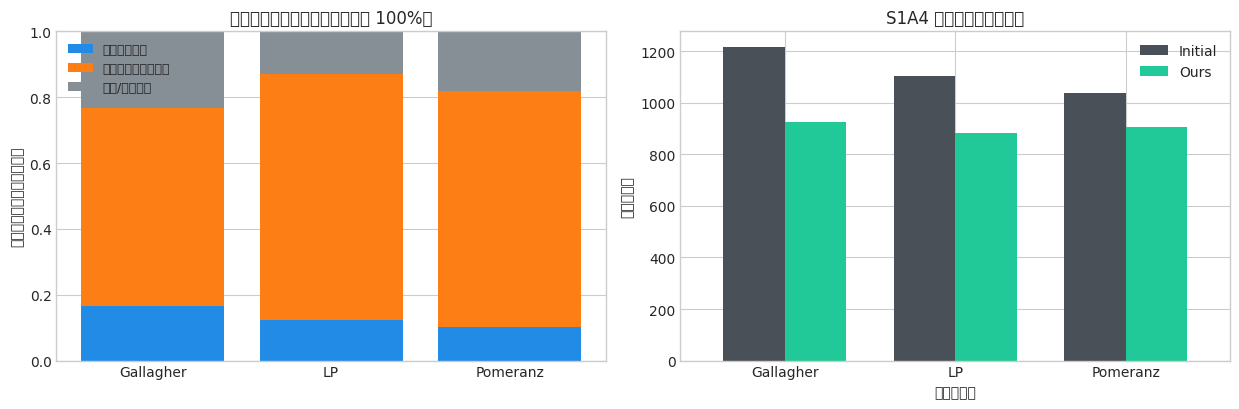

### S1A4 对各类初始失败的修复率

In [6]:
FAILURE_CLASS_ORDER = ['刚性错位主导', '低可靠区域错误主导', '其他/混合失败']
FAILURE_CLASS_COLORS = {
    '刚性错位主导': '#228be6', '低可靠区域错误主导': '#fd7e14', '其他/混合失败': '#868e96',
}

def assign_failure_type(row: pd.Series, threshold: float) -> str:
    if bool(row.get('is_perfect_layout', False)):
        return '完整正确（不属于失败分类）'
    if float(row['rigid_wrong_piece_ratio']) >= threshold:
        return FAILURE_CLASS_ORDER[0]
    if float(row['low_reliability_wrong_piece_ratio']) >= threshold:
        return FAILURE_CLASS_ORDER[1]
    return FAILURE_CLASS_ORDER[2]

failure_samples = samples.copy()
ours_failure_samples = ours_samples.copy()
if not failure_samples.empty:
    failure_samples['failure_type'] = failure_samples.apply(
        assign_failure_type, axis=1, threshold=FAILURE_DOMINANCE_THRESHOLD
    )
if not ours_failure_samples.empty:
    ours_failure_samples['failure_type'] = ours_failure_samples.apply(
        assign_failure_type, axis=1, threshold=FAILURE_DOMINANCE_THRESHOLD
    )

FULL_POPULATION_ANALYSIS = (not selected_filename and MAX_FAILED_SAMPLES_PER_TASK == 0)

def classify_all_failures(outcomes: pd.DataFrame, complete_samples: pd.DataFrame, stage: str):
    perfect_column = 'baseline_perfect' if stage == 'Initial' else 'ours_perfect'
    complete_column = 'baseline_complete' if stage == 'Initial' else 'ours_complete'
    failed = outcomes[~outcomes[perfect_column].astype(bool)].copy()
    lookup = complete_samples[[
        'initial_solver', 'task', 'saved_row', 'failure_type'
    ]].drop_duplicates(['initial_solver', 'task', 'saved_row'])
    failed = failed.merge(
        lookup, on=['initial_solver', 'task', 'saved_row'], how='left', validate='one_to_one'
    )
    failed.loc[~failed[complete_column].astype(bool), 'failure_type'] = FAILURE_CLASS_ORDER[2]
    if failed['failure_type'].isna().any():
        missing = failed.loc[failed['failure_type'].isna(), ['initial_solver', 'task', 'saved_row']].head()
        raise RuntimeError(f'{stage} 完整失败样本缺少结构标签；请使用全量模式重新运行：\n{missing}')
    failed['stage'] = stage
    return failed

if FULL_POPULATION_ANALYSIS:
    classified_initial = classify_all_failures(paired_outcomes, failure_samples, 'Initial')
    classified_ours = classify_all_failures(paired_outcomes, ours_failure_samples, 'Ours')
    classified_outcomes = classified_initial.copy()
    classified_outcomes['repaired_to_perfect'] = classified_outcomes['ours_perfect'].astype(bool)
    all_classified = pd.concat([classified_initial, classified_ours], ignore_index=True)

    counts = (
        all_classified.groupby(['initial_solver', 'stage', 'failure_type']).size()
        .unstack(fill_value=0).reindex(columns=FAILURE_CLASS_ORDER, fill_value=0)
    )
    counts['失败总数'] = counts.sum(axis=1)
    for category in FAILURE_CLASS_ORDER:
        counts[f'{category}比例'] = counts[category] / counts['失败总数']
    display(Markdown('### 三种初始求解器：失败构成与 S1A4 残余失败'))
    display(counts.style.format({f'{c}比例': '{:.1%}' for c in FAILURE_CLASS_ORDER}))

    initial_counts = counts.xs('Initial', level='stage')[FAILURE_CLASS_ORDER]
    initial_shares = initial_counts.div(initial_counts.sum(axis=1), axis=0)
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
    bottom = np.zeros(len(initial_shares))
    x = np.arange(len(initial_shares))
    for category in FAILURE_CLASS_ORDER:
        values = initial_shares[category].to_numpy()
        axes[0].bar(x, values, bottom=bottom, color=FAILURE_CLASS_COLORS[category], label=category)
        bottom += values
    axes[0].set_xticks(x, initial_shares.index)
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel('占全部初始失败预测的比例')
    axes[0].set_title('初始失败的互斥构成（每列合计 100%）')
    axes[0].legend(frameon=False, fontsize=9)

    failure_totals = counts['失败总数'].unstack('stage').reindex(columns=['Initial', 'Ours'])
    failure_totals.plot(kind='bar', ax=axes[1], color=['#495057', '#20c997'], width=0.72)
    axes[1].set_title('S1A4 前后的失败预测总数')
    axes[1].set_xlabel('初始求解器'); axes[1].set_ylabel('失败预测数')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(frameon=False)
    fig.tight_layout()
    display(fig); plt.close(fig)

    repair_summary = (
        classified_outcomes.groupby(['initial_solver', 'failure_type'], observed=False)
        .agg(初始失败数=('repaired_to_perfect', 'size'), 修复为完整正确数=('repaired_to_perfect', 'sum'))
    )
    repair_summary['修复率'] = repair_summary['修复为完整正确数'] / repair_summary['初始失败数']
    display(Markdown('### S1A4 对各类初始失败的修复率'))
    display(repair_summary.style.format({'修复率': '{:.1%}'}))
else:
    classified_initial = pd.DataFrame()
    classified_ours = pd.DataFrame()
    classified_outcomes = pd.DataFrame()
    print('当前为快速/指定样本模式：跳过必须基于全部失败预测的总体比例和修复率。')

### 观察一：内部结构一致但整体位置错误

平移一致率为 1.0 表示组件内全部碎片都能通过同一个整体平移从预测位置到达真实位置；`coherent_misplacement` 还要求该平移非零。下面先按初始求解器给出样本级和组件级统计，再仅对 `VISUAL_SOLVER` 绘制定性案例。失败类型中的“刚性错位主导”还要求此类组件覆盖至少 40% 的错误碎片，因此它比“存在一个刚性错位组件”更严格。

,,analyzed_puzzle_samples,puzzle_samples_with_reliable_component,puzzle_samples_with_rigid_misplacement,median_largest_component_size,rate_with_reliable_component,rate_with_rigid_misplacement
initial_solver,task,,,,,,
Gallagher,grid10_erode2,1108,1108,420,74.0,100.0%,37.9%
LP,grid10_erode2,1071,1069,367,68.0,99.8%,34.3%
Pomeranz,grid10_erode2,1037,1037,305,78.0,100.0%,29.4%


,,components,median_size,mean_translation_consistency,median_internal_edge_accuracy,perfect_rigid_translation_rate,coherent_misplacement_rate
initial_solver,task,,,,,,
Gallagher,grid10_erode2,2357,18.0,92.9%,100.0%,66.5%,36.2%
LP,grid10_erode2,2575,11.0,93.7%,100.0%,71.6%,27.7%
Pomeranz,grid10_erode2,2099,19.0,90.9%,100.0%,53.6%,23.8%


/tmp/ipykernel_2499818/3440350193.py:47: UserWarning: Glyph 20219 (\N{CJK UNIFIED IDEOGRAPH-4EFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); display(axis.figure); plt.close(axis.figure)
/tmp/ipykernel_2499818/3440350193.py:47: UserWarning: Glyph 21153 (\N{CJK UNIFIED IDEOGRAPH-52A1}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); display(axis.figure); plt.close(axis.figure)
/tmp/ipykernel_2499818/3440350193.py:47: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); display(axis.figure); plt.close(axis.figure)
/tmp/ipykernel_2499818/3440350193.py:47: UserWarning: Glyph 21018 (\N{CJK UNIFIED IDEOGRAPH-521A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); display(axis.figure); plt.close(axis.figure)
/tmp/ipykernel_2499818/3440350193.py:47: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); display(axis.figure); plt.close(axis.figure)


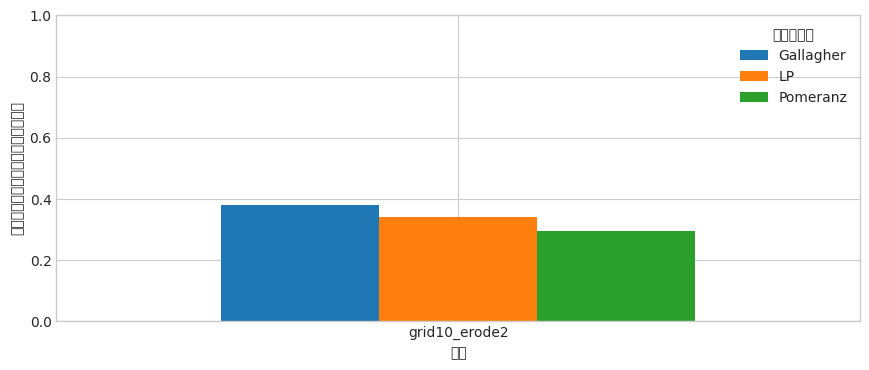

In [7]:
sample_summary = (
    samples.groupby(['initial_solver', 'task'])
    .agg(
        analyzed_puzzle_samples=('lsej_id', 'size'),
        puzzle_samples_with_reliable_component=('has_reliable_component', 'sum'),
        puzzle_samples_with_rigid_misplacement=('has_coherent_misplacement', 'sum'),
        median_largest_component_size=('largest_component_size', 'median'),
    )
)
sample_summary['rate_with_reliable_component'] = (
    sample_summary['puzzle_samples_with_reliable_component'] / sample_summary['analyzed_puzzle_samples']
)
sample_summary['rate_with_rigid_misplacement'] = (
    sample_summary['puzzle_samples_with_rigid_misplacement'] / sample_summary['analyzed_puzzle_samples']
)
display(sample_summary.style.format({
    'rate_with_reliable_component': '{:.1%}', 'rate_with_rigid_misplacement': '{:.1%}',
    'median_largest_component_size': '{:.1f}',
}))

if components.empty:
    component_summary = pd.DataFrame()
    print('当前没有满足最小规模要求的可靠组件。')
else:
    component_summary = (
        components.groupby(['initial_solver', 'task'])
        .agg(
            components=('component_index', 'size'), median_size=('size', 'median'),
            mean_translation_consistency=('translation_consistency', 'mean'),
            median_internal_edge_accuracy=('internal_edge_accuracy', 'median'),
            perfect_rigid_translation_rate=('perfect_rigid_translation', 'mean'),
            coherent_misplacement_rate=('coherent_misplacement', 'mean'),
        )
    )
    display(component_summary.style.format({
        'median_size': '{:.1f}', 'mean_translation_consistency': '{:.1%}',
        'median_internal_edge_accuracy': '{:.1%}', 'perfect_rigid_translation_rate': '{:.1%}',
        'coherent_misplacement_rate': '{:.1%}',
    }))

rigid_presence = sample_summary['rate_with_rigid_misplacement'].unstack('initial_solver')
if not rigid_presence.empty:
    axis = rigid_presence.plot(kind='bar', figsize=(8.8, 3.8), width=0.72)
    axis.set(ylabel='含刚性错位组件的完整失败样本比例', xlabel='任务', ylim=(0, 1))
    axis.tick_params(axis='x', rotation=0)
    axis.legend(title='初始求解器', frameon=False)
    plt.tight_layout(); display(axis.figure); plt.close(axis.figure)

#### 观察一的定性案例

定性图只从 `VISUAL_SOLVER` 的“刚性错位主导”样本中选择最大组件，展示打乱输入、该初始求解器结果、真实布局和 S1A4 结果。这样定量比较保持三求解器并列，论文中的案例图仍然简洁。

,数值
组件编号,0
组件大小,88
碎片编号,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18..."
平移一致率,1.0
主导行平移,0
主导列平移,-1
主导平移是否非零,True
是否为完全刚性平移,True
是否为刚性错位组件,True
绝对位置正确率,0.0


#### 最大刚性错位组件的四列对照

样本 **LSEJ_008309**（grid10_erode2）中，最大的刚性错位组件包含 **88** 块碎片，从求解器位置到真实位置的整体平移为 $\Delta=(0, -1)$。四列依次为原始打乱输入、Gallagher 求解结果、真实布局和 Ours 结果。Gallagher 与真实布局中的青色粗实线外轮廓标出同一个最大刚性错位组件；Ours 不绘制该组件轮廓。求解结果中的绿色/红色细框分别表示绝对位置正确/错误（AA = 0/100）。当前不压暗非组件碎片。

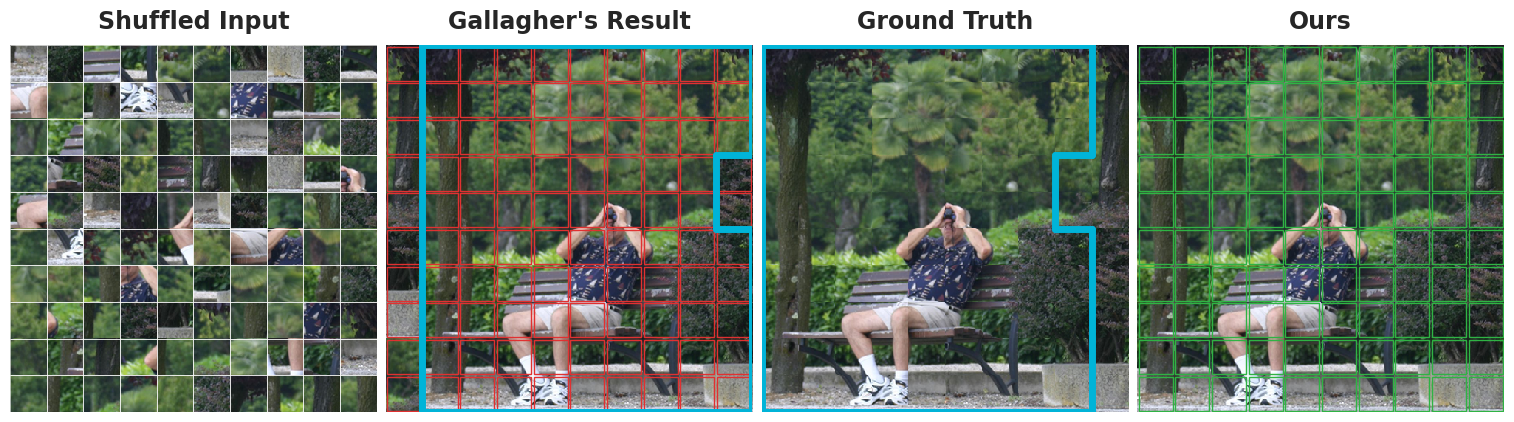

#### 同一组件的邻接可靠性图

/home/yecx/anaconda3/envs/jigsaw_puzzle/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37051 (\N{CJK UNIFIED IDEOGRAPH-90BB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yecx/anaconda3/envs/jigsaw_puzzle/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yecx/anaconda3/envs/jigsaw_puzzle/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yecx/anaconda3/envs/jigsaw_puzzle/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38752 (\N{CJK UNIFIED IDEOGRAPH-9760}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yecx/anaconda3/envs/jigsaw_puzzle/lib/python3.10/site-

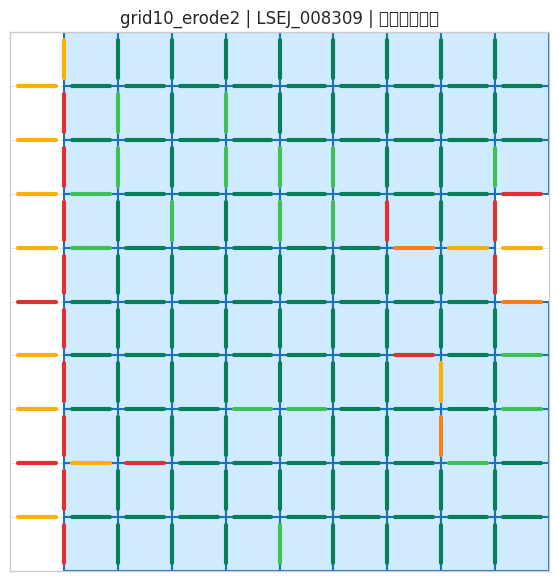

In [8]:
def solver_result_title(solver: str) -> str:
    return f"{solver}'s Result" if solver in {'Gallagher', 'Pomeranz'} else f'{solver} Result'

def solver_result_title(solver: str) -> str:
    return f"{solver}'s Result" if solver in {'Gallagher', 'Pomeranz'} else f'{solver} Result'

def solver_result_title(solver: str) -> str:
    return f"{solver}'s Result" if solver in {'Gallagher', 'Pomeranz'} else f'{solver} Result'

def solver_result_title(solver: str) -> str:
    return f"{solver}'s Result" if solver in {'Gallagher', 'Pomeranz'} else f'{solver} Result'

# 四列对照：打乱输入、带 AA 正误框的所选初始求解器结果、真实布局和 Ours。
NON_COMPONENT_DIM_ALPHA = 0  # 非组件区域只轻微压暗，保留图像细节

def draw_component_on_puzzle(
    axis, pieces, positions, grid, title, component_pieces=None, aa_target=None,
    dim_alpha=0.0, show_piece_grid=False,
):
    layout = positions_to_layout(positions, grid)
    component_pieces = set() if component_pieces is None else set(component_pieces)
    component_positions = {divmod(int(positions[piece]), grid) for piece in component_pieces}
    for row in range(grid):
        for column in range(grid):
            piece = int(layout[row, column])
            y = grid - row - 1
            axis.imshow(
                pieces[piece], extent=(column, column + 1, y, y + 1),
                origin='upper', interpolation='nearest',
            )
            if show_piece_grid:
                axis.add_patch(Rectangle(
                    (column, y), 1, 1, fill=False, edgecolor='white', linewidth=0.55, alpha=0.8, zorder=2
                ))
            if component_pieces and piece not in component_pieces and dim_alpha > 0:
                axis.add_patch(Rectangle(
                    (column, y), 1, 1, facecolor='white', edgecolor='none', alpha=dim_alpha, zorder=2
                ))
            if aa_target is not None:
                aa_color = '#2fb344' if int(positions[piece]) == int(aa_target[piece]) else '#e03131'
                axis.add_patch(Rectangle(
                    (column + 0.035, y + 0.035), 0.93, 0.93, fill=False,
                    edgecolor=aa_color, linewidth=1.0, zorder=5,
                ))

    # 只绘制组件的外轮廓，不用碎片内部网格线破坏整体观感。
    boundary_color = '#00b4d8'
    for row, column in component_positions:
        y = grid - row - 1
        if (row - 1, column) not in component_positions:
            axis.plot([column, column + 1], [y + 1, y + 1], color=boundary_color, linewidth=5.0, zorder=7)
        if (row + 1, column) not in component_positions:
            axis.plot([column, column + 1], [y, y], color=boundary_color, linewidth=5.0, zorder=7)
        if (row, column - 1) not in component_positions:
            axis.plot([column, column], [y, y + 1], color=boundary_color, linewidth=5.0, zorder=7)
        if (row, column + 1) not in component_positions:
            axis.plot([column + 1, column + 1], [y, y + 1], color=boundary_color, linewidth=5.0, zorder=7)
    axis.set(xlim=(0, grid), ylim=(0, grid), aspect='equal')
    axis.set_title(title, fontsize=17, fontweight='semibold', pad=12)
    axis.set_xticks([]); axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(False)

def plot_largest_rigid_component(component_row: pd.Series):
    initial_solver = str(component_row['initial_solver'])
    task = str(component_row['task'])
    key = (initial_solver, task)
    saved_row = int(component_row['saved_row'])
    result_dir = REFERENCE_RESULT_DIRS[task]
    metadata = json.loads((result_dir / 'metrics.json').read_text(encoding='utf-8'))
    prediction = S1A4_BASELINE_PREDICTIONS[key][saved_row].copy()
    ours_prediction = S1A4_SELECTED_PREDICTIONS[key][saved_row].copy()
    target = S1A4_TARGETS[key][saved_row].copy()
    grid = int(round(np.sqrt(prediction.size)))
    dataset_index = int(S1A4_SAMPLE_INDICES[key][saved_row])
    archive_lsej_id = str(S1A4_LSEJ_IDS[key][saved_row])
    if archive_lsej_id != str(component_row['lsej_id']):
        raise RuntimeError('组件记录与 predictions.npz 中的样本不一致')

    dataset_class = load_official_dataset_class()
    dataset = dataset_class(LOCAL_DATA_ROOTS[task], split=metadata['split'], task=task, normalize=False)
    sample = dataset[dataset_index]
    pieces = list(chw_uint8_to_hwc_numpy(sample['pieces']))
    component_pieces = {int(piece) for piece in str(component_row['piece_ids']).split(',')}

    shuffled_positions = np.arange(grid * grid, dtype=np.int64)
    aa_correct = int(np.count_nonzero(prediction == target))
    row_shift = int(component_row['dominant_row_shift'])
    column_shift = int(component_row['dominant_column_shift'])
    dim_note = (
        '当前不压暗非组件碎片。' if NON_COMPONENT_DIM_ALPHA <= 0
        else f'非组件碎片仅以 {NON_COMPONENT_DIM_ALPHA:.0%} 的透明度轻微淡化。'
    )
    display(Markdown(
        f"样本 **{component_row['lsej_id']}**（{task}）中，最大的刚性错位组件包含 "
        f"**{int(component_row['size'])}** 块碎片，从求解器位置到真实位置的整体平移为 "
        f"$\\Delta=({row_shift}, {column_shift})$。四列依次为原始打乱输入、Gallagher 求解结果、"
        f"真实布局和 Ours 结果。{initial_solver} 与真实布局中的青色粗实线外轮廓"
        f"标出同一个最大刚性错位组件；Ours 不绘制该组件轮廓。"
        f"求解结果中的绿色/红色细框"
        f"分别表示绝对位置正确/错误（AA = {aa_correct}/{grid * grid}）。{dim_note}"
    ))
    fig, axes = plt.subplots(
        1, 4, figsize=(15.0, 4.1), constrained_layout=False, gridspec_kw={'wspace': 0.025}
    )
    draw_component_on_puzzle(
        axes[0], pieces, shuffled_positions, grid, 'Shuffled Input', show_piece_grid=True
    )
    draw_component_on_puzzle(
        axes[1], pieces, prediction, grid, solver_result_title(initial_solver),
        component_pieces=component_pieces, aa_target=target, dim_alpha=NON_COMPONENT_DIM_ALPHA,
    )
    draw_component_on_puzzle(
        axes[2], pieces, target, grid, 'Ground Truth',
        component_pieces=component_pieces, dim_alpha=NON_COMPONENT_DIM_ALPHA,
    )
    draw_component_on_puzzle(
        axes[3], pieces, ours_prediction, grid, 'Ours',
        aa_target=target, dim_alpha=NON_COMPONENT_DIM_ALPHA,
    )
    fig.subplots_adjust(left=0.002, right=0.998, bottom=0.002, top=0.90, wspace=0.025)
    display(fig)
    plt.close(fig)

# 仅依据分数和预测排列绘制可靠性图；蓝色单元格组成同一个刚性错位组件。
def plot_reliability_map(edges_df: pd.DataFrame, component_row: pd.Series, grid: int = 10):
    task, lsej_id = component_row['task'], component_row['lsej_id']
    initial_solver = str(component_row['initial_solver'])
    sample_edges = edges_df[(edges_df['initial_solver'] == initial_solver) & (edges_df['task'] == task) & (edges_df['lsej_id'] == lsej_id)]
    component_pieces = {int(piece) for piece in str(component_row['piece_ids']).split(',')}
    piece_positions = {}
    for edge in sample_edges.itertuples():
        piece_positions[int(edge.anchor)] = (int(edge.row), int(edge.column))
        dr, dc = DIRECTION_OFFSETS[int(edge.direction)]
        piece_positions[int(edge.candidate)] = (int(edge.row) + dr, int(edge.column) + dc)
    fig, axis = plt.subplots(figsize=(7, 7))
    for piece in component_pieces:
        row, column = piece_positions[piece]
        axis.add_patch(Rectangle((column, grid - 1 - row), 1, 1, facecolor='#d0ebff', edgecolor='#1971c2', linewidth=1.5))
    for edge in sample_edges.itertuples():
        color = BUCKET_COLORS[BUCKET_ORDER.index(edge.reliability_bucket)]
        row, column = int(edge.row), int(edge.column)
        if int(edge.direction) == RIGHT:
            x, y = column + 1, grid - row - 0.5
            axis.plot([x, x], [y - 0.35, y + 0.35], color=color, linewidth=3)
        else:
            x, y = column + 0.5, grid - row - 1
            axis.plot([x - 0.35, x + 0.35], [y, y], color=color, linewidth=3)
    axis.set(xlim=(0, grid), ylim=(0, grid), aspect='equal', title=f'{task} | {lsej_id} | 邻接可靠性图')
    axis.set_xticks(range(grid + 1)); axis.set_yticks(range(grid + 1)); axis.grid(color='#dee2e6', linewidth=0.7)
    axis.tick_params(labelbottom=False, labelleft=False)
    display(fig)
    plt.close(fig)

rigid_visual_samples = failure_samples[
    (failure_samples['initial_solver'] == VISUAL_SOLVER)
    & (failure_samples['failure_type'].astype('object') == '刚性错位主导')
][['initial_solver', 'task', 'lsej_id']]
if components.empty or 'coherent_misplacement' not in components.columns or rigid_visual_samples.empty:
    exemplars = pd.DataFrame()
else:
    exemplars = (
        components[(components['initial_solver'] == VISUAL_SOLVER) & components['coherent_misplacement'].astype(bool)]
        .merge(rigid_visual_samples, on=['initial_solver', 'task', 'lsej_id'], how='inner', validate='many_to_one')
        .sort_values('size', ascending=False)
    )
if len(exemplars):
    exemplar = exemplars.iloc[0]
    exemplar_labels = {
        'initial_solver': '初始求解器', 'task': '任务', 'lsej_id': 'LSEJ ID', 'saved_row': '结果行号',
        'component_index': '组件编号', 'size': '组件大小', 'piece_ids': '碎片编号',
        'translation_consistency': '平移一致率',
        'dominant_row_shift': '主导行平移', 'dominant_column_shift': '主导列平移',
        'nonzero_dominant_shift': '主导平移是否非零',
        'perfect_rigid_translation': '是否为完全刚性平移',
        'coherent_misplacement': '是否为刚性错位组件',
        'absolute_piece_accuracy': '绝对位置正确率',
        'internal_edges': '内部邻接边数', 'internal_edge_accuracy': '内部邻接正确率',
        'supported_internal_edges': '环支持内部边数', 'supported_edge_accuracy': '环支持边正确率',
    }
    display(exemplar.rename(index=exemplar_labels).to_frame('数值'))
    display(Markdown('#### 最大刚性错位组件的四列对照'))
    plot_largest_rigid_component(exemplar)
    display(Markdown('#### 同一组件的邻接可靠性图'))
    plot_reliability_map(edges, exemplar)
else:
    if selected_filename and not failure_samples.empty:
        selected_type = str(failure_samples.iloc[0]['failure_type'])
        print(f'跳过观察一可视化：指定样本属于“{selected_type}”，不是“刚性错位主导”。')
    else:
        print('当前分析子集中没有可用于观察一的刚性错位主导样本。')


### 观察二：错误是否集中于低可靠区域

“某可靠性等级有多容易出错”和“全部错误主要分布在哪些可靠性等级”是两个不同问题。下面对三种初始求解器同时给出错误率 $P(\mathrm{错误}\mid\mathrm{等级})$ 与错误构成 $P(\mathrm{等级}\mid\mathrm{错误})$。其中不具备完整环支持的等级合并为低可靠区域；样本级失败分类进一步检验这些区域能否解释至少 40% 的错误碎片。

,initial_solver,task,reliability_bucket,edges,incorrect_edges,error_rate,share_of_all_incorrect_edges
0,Gallagher,grid10_erode2,mutual Top-1 + cycle,121910,1262,1.0%,3.3%
1,Gallagher,grid10_erode2,mutual Top-2..3 + cycle,15275,1323,8.7%,3.4%
2,Gallagher,grid10_erode2,"mutual Top-3, no cycle",25009,7683,30.7%,19.8%
4,Gallagher,grid10_erode2,one-way Top-3,7141,3310,46.4%,8.5%
3,Gallagher,grid10_erode2,neither Top-3,30105,25235,83.8%,65.0%
5,LP,grid10_erode2,mutual Top-1 + cycle,103879,980,0.9%,2.5%
6,LP,grid10_erode2,mutual Top-2..3 + cycle,18091,1214,6.7%,3.1%
7,LP,grid10_erode2,"mutual Top-3, no cycle",28115,6894,24.5%,17.8%
9,LP,grid10_erode2,one-way Top-3,11989,4924,41.1%,12.7%
8,LP,grid10_erode2,neither Top-3,30706,24798,80.8%,63.9%


/tmp/ipykernel_2499818/1251007903.py:45: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); display(fig); plt.close(fig)
/tmp/ipykernel_2499818/1251007903.py:45: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); display(fig); plt.close(fig)
/tmp/ipykernel_2499818/1251007903.py:45: UserWarning: Glyph 29615 (\N{CJK UNIFIED IDEOGRAPH-73AF}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); display(fig); plt.close(fig)
/tmp/ipykernel_2499818/1251007903.py:45: UserWarning: Glyph 25903 (\N{CJK UNIFIED IDEOGRAPH-652F}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); display(fig); plt.close(fig)
/tmp/ipykernel_2499818/1251007903.py:45: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); display(fig); plt.close(fig)
/tmp/ipykernel_2499818/1251007903.py:45: UserWarning: Glyph 65292 (\N{FULLWIDTH 

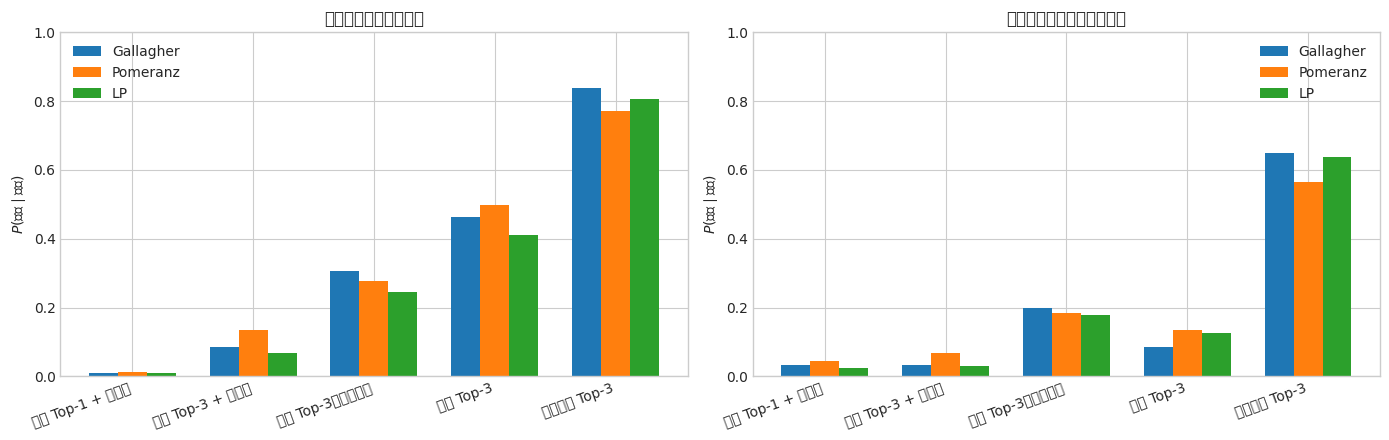

In [9]:
edge_summary = (
    edges.assign(error=~edges['correct'].astype(bool))
    .groupby(['initial_solver', 'task', 'reliability_bucket'], observed=False)
    .agg(edges=('error', 'size'), incorrect_edges=('error', 'sum'))
    .reset_index()
)
edge_summary['error_rate'] = edge_summary['incorrect_edges'] / edge_summary['edges']
incorrect_totals = edge_summary.groupby(['initial_solver', 'task'])['incorrect_edges'].transform('sum')
edge_summary['share_of_all_incorrect_edges'] = np.divide(
    edge_summary['incorrect_edges'], incorrect_totals,
    out=np.zeros(len(edge_summary), dtype=float), where=incorrect_totals.to_numpy() > 0,
)
edge_summary['reliability_bucket'] = pd.Categorical(
    edge_summary['reliability_bucket'], categories=BUCKET_ORDER, ordered=True
)
display(edge_summary.sort_values(['initial_solver', 'task', 'reliability_bucket']).style.format({
    'error_rate': '{:.1%}', 'share_of_all_incorrect_edges': '{:.1%}',
}))

plot_data = edge_summary.groupby(['initial_solver', 'reliability_bucket'], observed=False).agg(
    edges=('edges', 'sum'), incorrect_edges=('incorrect_edges', 'sum')
).reset_index()
plot_data['error_rate'] = plot_data['incorrect_edges'] / plot_data['edges']
solver_error_totals = plot_data.groupby('initial_solver')['incorrect_edges'].transform('sum')
plot_data['error_share'] = np.divide(
    plot_data['incorrect_edges'], solver_error_totals,
    out=np.zeros(len(plot_data), dtype=float), where=solver_error_totals.to_numpy() > 0,
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
width = 0.24
x = np.arange(len(BUCKET_ORDER))
for index, solver in enumerate(INITIAL_SOLVERS):
    solver_rows = plot_data[plot_data['initial_solver'] == solver].set_index('reliability_bucket').reindex(BUCKET_ORDER)
    offset = (index - (len(INITIAL_SOLVERS) - 1) / 2) * width
    axes[0].bar(x + offset, solver_rows['error_rate'], width=width, label=solver)
    axes[1].bar(x + offset, solver_rows['error_share'], width=width, label=solver)
axes[0].set_title('各可靠性等级的错误率')
axes[0].set_ylabel(r'$P(\mathrm{错误}\mid\mathrm{等级})$')
axes[1].set_title('全部错误邻接的可靠性构成')
axes[1].set_ylabel(r'$P(\mathrm{等级}\mid\mathrm{错误})$')
for axis in axes:
    axis.set_xticks(x, [BUCKET_LABELS[b] for b in BUCKET_ORDER], rotation=20, ha='right')
    axis.set_ylim(0, 1)
    axis.legend(frameon=False)
fig.tight_layout(); display(fig); plt.close(fig)

#### 观察二的定性案例

定性图只从 `VISUAL_SOLVER` 的“低可靠区域错误主导”样本中选择。四列依次展示该初始求解器结果、五级可靠性图、真实布局和 S1A4 结果；连续热力图作为补充保留。

#### 观察二的四列定性案例｜低可靠区域错误主导样本

样本 **LSEJ_000081**（grid10_erode2）包含 **51** 个绝对位置错误碎片，其中 **100.0%** 位于低可靠区域；错误邻接中有 **100.0%** 属于非环支持等级。第一列红/绿细框表示绝对位置错误/正确；第二列浅蓝单元格表示环支持可靠组件，灰色单元格表示低可靠区域，彩色线段表示五级邻接可靠性；第四列为 S1A4 的最终结果。

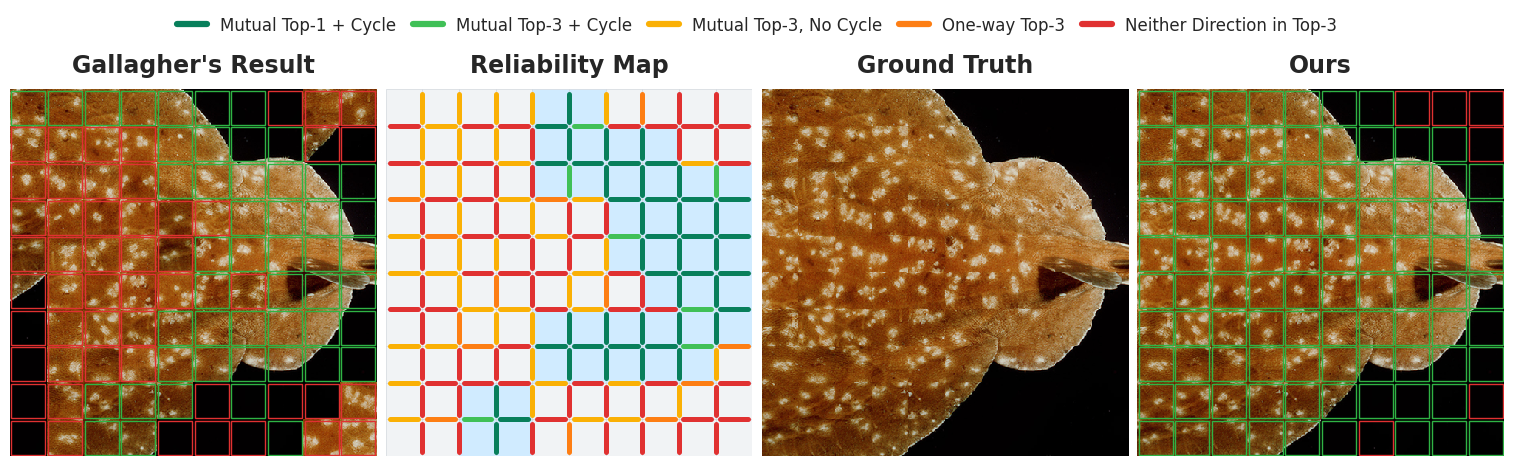

**拼图内相对置信度热力图。** 第二列使用 $\mathrm{confidence}=1-\mathrm{score}$，并将本图所有当前邻接的第 5/95 百分位 分别映射为红/绿；颜色表示本张拼图内部的相对高低。

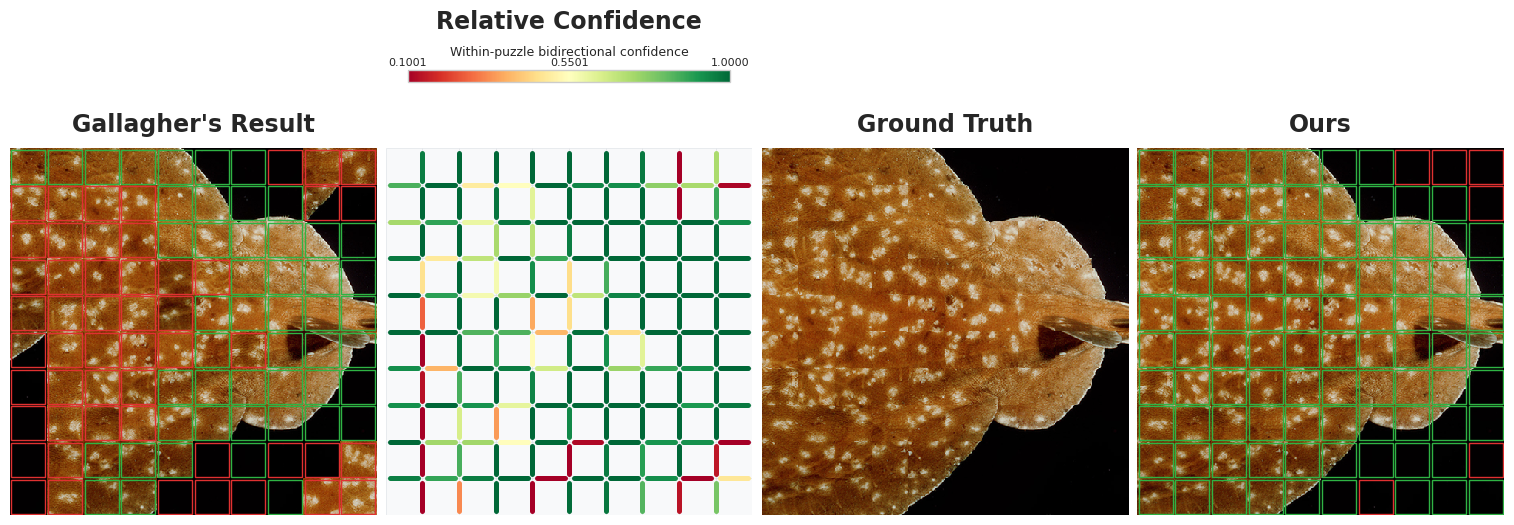

In [10]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

OBSERVATION_TWO_LEGEND_LABELS = [
    'Mutual Top-1 + Cycle',
    f'Mutual Top-{MUTUAL_TOP_K} + Cycle',
    f'Mutual Top-{MUTUAL_TOP_K}, No Cycle',
    f'One-way Top-{MUTUAL_TOP_K}',
    f'Neither Direction in Top-{MUTUAL_TOP_K}',
]

def draw_reliability_panel(axis, sample_edges: pd.DataFrame, prediction: np.ndarray, reliable_pieces: set[int], grid: int):
    layout = positions_to_layout(prediction, grid)
    for row in range(grid):
        for column in range(grid):
            piece = int(layout[row, column])
            y = grid - row - 1
            facecolor = '#d0ebff' if piece in reliable_pieces else '#f1f3f5'
            axis.add_patch(Rectangle(
                (column, y), 1, 1, facecolor=facecolor,
                edgecolor='#ced4da', linewidth=0.45, zorder=1,
            ))

    for edge in sample_edges.itertuples():
        color = BUCKET_COLORS[BUCKET_ORDER.index(edge.reliability_bucket)]
        row, column = int(edge.row), int(edge.column)
        if int(edge.direction) == RIGHT:
            x, y = column + 1, grid - row - 0.5
            axis.plot([x, x], [y - 0.38, y + 0.38], color=color, linewidth=3.6, zorder=3)
        else:
            x, y = column + 0.5, grid - row - 1
            axis.plot([x - 0.38, x + 0.38], [y, y], color=color, linewidth=3.6, zorder=3)

    axis.set(xlim=(0, grid), ylim=(0, grid), aspect='equal')
    axis.set_title('Reliability Map', fontsize=17, fontweight='semibold', pad=12)
    axis.set_xticks([]); axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(False)


def draw_continuous_confidence_panel(axis, sample_edges: pd.DataFrame, grid: int):
    # metric_postprocess_scores 已逐查询归一化并进行正反向对称化：score 越小越兼容。
    confidences = np.clip(1.0 - sample_edges['score'].to_numpy(dtype=float), 0.0, 1.0)
    scale_low, scale_high = np.quantile(confidences, [0.05, 0.95])
    if scale_high - scale_low <= 1e-8:
        scale_low, scale_high = float(confidences.min()), float(confidences.max())
    if scale_high - scale_low <= 1e-8:
        scale_low = max(0.0, float(scale_low) - 0.01)
        scale_high = min(1.0, float(scale_high) + 0.01)
    normalization = Normalize(vmin=scale_low, vmax=scale_high, clip=True)
    colormap = plt.get_cmap('RdYlGn')
    for row in range(grid):
        for column in range(grid):
            y = grid - row - 1
            axis.add_patch(Rectangle(
                (column, y), 1, 1, facecolor='#f8f9fa',
                edgecolor='#dee2e6', linewidth=0.45, zorder=1,
            ))

    for edge in sample_edges.itertuples():
        confidence = float(np.clip(1.0 - float(edge.score), 0.0, 1.0))
        color = colormap(normalization(confidence))
        row, column = int(edge.row), int(edge.column)
        if int(edge.direction) == RIGHT:
            x, y = column + 1, grid - row - 0.5
            axis.plot([x, x], [y - 0.38, y + 0.38], color=color, linewidth=3.6, zorder=3)
        else:
            x, y = column + 0.5, grid - row - 1
            axis.plot([x - 0.38, x + 0.38], [y, y], color=color, linewidth=3.6, zorder=3)

    axis.set(xlim=(0, grid), ylim=(0, grid), aspect='equal')
    axis.set_title('Relative Confidence', fontsize=17, fontweight='semibold', pad=12)
    axis.set_xticks([]); axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(False)
    return ScalarMappable(norm=normalization, cmap=colormap), (scale_low, scale_high)


def plot_observation_two_example(sample_row: pd.Series):
    initial_solver = str(sample_row['initial_solver'])
    task = str(sample_row['task'])
    key = (initial_solver, task)
    saved_row = int(sample_row['saved_row'])
    result_dir = REFERENCE_RESULT_DIRS[task]
    metadata = json.loads((result_dir / 'metrics.json').read_text(encoding='utf-8'))
    prediction = S1A4_BASELINE_PREDICTIONS[key][saved_row].copy()
    ours_prediction = S1A4_SELECTED_PREDICTIONS[key][saved_row].copy()
    target = S1A4_TARGETS[key][saved_row].copy()
    grid = int(round(np.sqrt(prediction.size)))
    dataset_index = int(S1A4_SAMPLE_INDICES[key][saved_row])
    archive_lsej_id = str(S1A4_LSEJ_IDS[key][saved_row])
    if archive_lsej_id != str(sample_row['lsej_id']):
        raise RuntimeError('样本记录与 predictions.npz 中的 LSEJ ID 不一致')

    dataset_class = load_official_dataset_class()
    dataset = dataset_class(LOCAL_DATA_ROOTS[task], split=metadata['split'], task=task, normalize=False)
    sample = dataset[dataset_index]
    pieces = list(chw_uint8_to_hwc_numpy(sample['pieces']))
    sample_edges = edges[
        (edges['initial_solver'] == initial_solver) & (edges['task'] == task) & (edges['lsej_id'] == str(sample_row['lsej_id']))
    ]
    sample_components = components[
        (components['initial_solver'] == initial_solver) & (components['task'] == task) & (components['lsej_id'] == str(sample_row['lsej_id']))
    ] if not components.empty else pd.DataFrame()
    reliable_pieces = set()
    if not sample_components.empty:
        for piece_ids in sample_components['piece_ids'].astype(str):
            reliable_pieces.update(int(piece) for piece in piece_ids.split(',') if piece)

    display(Markdown(
        f"样本 **{sample_row['lsej_id']}**（{task}）包含 **{int(sample_row['wrong_pieces'])}** 个"
        f"绝对位置错误碎片，其中 **{float(sample_row['low_reliability_wrong_piece_ratio']):.1%}** 位于"
        f"低可靠区域；错误邻接中有 **{float(sample_row['low_reliability_incorrect_adjacency_ratio']):.1%}** "
        f"属于非环支持等级。第一列红/绿细框表示绝对位置错误/正确；第二列浅蓝单元格表示环支持"
        f"可靠组件，灰色单元格表示低可靠区域，彩色线段表示五级邻接可靠性；"
        f"第四列为 S1A4 的最终结果。"
    ))

    fig, axes = plt.subplots(
        1, 4, figsize=(15.0, 4.73), constrained_layout=False,
        gridspec_kw={'wspace': 0.025},
    )
    draw_component_on_puzzle(
        axes[0], pieces, prediction, grid, solver_result_title(initial_solver), aa_target=target
    )
    draw_reliability_panel(axes[1], sample_edges, prediction, reliable_pieces, grid)
    draw_component_on_puzzle(axes[2], pieces, target, grid, 'Ground Truth')
    draw_component_on_puzzle(axes[3], pieces, ours_prediction, grid, 'Ours', aa_target=target)

    legend_handles = [
        Line2D([0], [0], color=color, linewidth=4.5, label=label)
        for label, color in zip(OBSERVATION_TWO_LEGEND_LABELS, BUCKET_COLORS)
    ]
    fig.legend(
        handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.995),
        ncol=5, frameon=False, fontsize=12, columnspacing=1.0, handlelength=1.8,
    )
    fig.subplots_adjust(left=0.002, right=0.998, bottom=0.002, top=0.84, wspace=0.025)
    display(fig)
    plt.close(fig)

    display(Markdown(
        '**拼图内相对置信度热力图。** 第二列使用 '
        '$\\mathrm{confidence}=1-\\mathrm{score}$，并将本图所有当前邻接的第 5/95 百分位 '
        '分别映射为红/绿；颜色表示本张拼图内部的相对高低。'
    ))
    continuous_fig, continuous_axes = plt.subplots(
        1, 4, figsize=(15.0, 4.73), constrained_layout=False,
        gridspec_kw={'wspace': 0.025},
    )
    draw_component_on_puzzle(
        continuous_axes[0], pieces, prediction, grid,
        solver_result_title(initial_solver), aa_target=target,
    )
    confidence_mappable, confidence_scale = draw_continuous_confidence_panel(
        continuous_axes[1], sample_edges, grid
    )
    draw_component_on_puzzle(
        continuous_axes[2], pieces, target, grid, 'Ground Truth'
    )
    draw_component_on_puzzle(
        continuous_axes[3], pieces, ours_prediction, grid, 'Ours', aa_target=target
    )
    colorbar_axis = continuous_axes[1].inset_axes([0.06, 1.18, 0.88, 0.035])
    colorbar = continuous_fig.colorbar(
        confidence_mappable, cax=colorbar_axis, orientation='horizontal'
    )
    scale_low, scale_high = confidence_scale
    colorbar.set_ticks([scale_low, 0.5 * (scale_low + scale_high), scale_high])
    colorbar.set_label('Within-puzzle bidirectional confidence', fontsize=9, labelpad=2)
    colorbar.ax.xaxis.set_ticks_position('top')
    colorbar.ax.xaxis.set_label_position('top')
    colorbar.ax.tick_params(labelsize=8, pad=1)
    continuous_fig.subplots_adjust(
        left=0.002, right=0.998, bottom=0.002, top=0.78, wspace=0.025
    )
    display(continuous_fig)
    plt.close(continuous_fig)


low_reliability_mask = (
    (failure_samples['initial_solver'] == VISUAL_SOLVER)
    & (failure_samples['failure_type'].astype('object') == '低可靠区域错误主导')
)
observation_two_candidates = failure_samples[low_reliability_mask].copy()
observation_two_selection_note = (
    '指定文件名的低可靠区域错误主导样本'
    if selected_filename else '低可靠区域错误主导样本'
)

if observation_two_candidates.empty:
    if selected_filename and not failure_samples.empty:
        selected_type = str(failure_samples.iloc[0]['failure_type'])
        print(f'跳过观察二可视化：指定样本属于“{selected_type}”，不是“低可靠区域错误主导”。')
    else:
        print('当前分析集合中没有可用于观察二的低可靠区域错误主导样本。')
else:
    observation_two_exemplar = observation_two_candidates.sort_values(
        ['low_reliability_wrong_piece_ratio', 'wrong_pieces',
         'low_reliability_incorrect_adjacency_ratio'],
        ascending=[False, False, False],
    ).iloc[0]
    display(Markdown(f'#### 观察二的四列定性案例｜{observation_two_selection_note}'))
    plot_observation_two_example(observation_two_exemplar)


## 阈值敏感性分析

主分析采用 40% 主导阈值，并以 50%、70% 和 90% 作为更严格条件。敏感性分析按初始求解器分别报告三类失败比例，检验跨求解器结论是否依赖单一阈值。仅全量模式生成该表。

In [11]:
if not FULL_POPULATION_ANALYSIS:
    print('快速/指定样本模式：跳过总体阈值敏感性统计。')
else:
    sensitivity_frames = []
    for threshold in SENSITIVITY_THRESHOLDS:
        threshold_samples = samples.copy()
        threshold_samples['failure_type'] = threshold_samples.apply(
            assign_failure_type, axis=1, threshold=threshold
        )
        threshold_classified = classify_all_failures(paired_outcomes, threshold_samples, 'Initial')
        summary = (
            threshold_classified.groupby(['initial_solver', 'task', 'failure_type']).size()
            .rename('count').reset_index()
        )
        totals = summary.groupby(['initial_solver', 'task'])['count'].transform('sum')
        summary['share'] = summary['count'] / totals
        summary['threshold'] = threshold
        sensitivity_frames.append(summary)
    sensitivity = pd.concat(sensitivity_frames, ignore_index=True)
    sensitivity_table = sensitivity.pivot_table(
        index=['initial_solver', 'task', 'threshold'], columns='failure_type',
        values='share', fill_value=0,
    ).reindex(columns=FAILURE_CLASS_ORDER, fill_value=0)
    display(sensitivity_table.style.format('{:.1%}'))

## 样本级审计明细

全量模式展示每个初始求解器前若干个完整失败样本的分类依据，便于人工核验。由于不完整预测没有完整网格邻接，其统计上并入“其他/混合失败”，但不会伪造组件或邻接证据。

In [12]:
if not failure_samples.empty:
    sample_failure_preview = failure_samples[[
        'initial_solver', 'task', 'lsej_id', 'wrong_pieces',
        'rigid_wrong_piece_ratio', 'low_reliability_wrong_piece_ratio',
        'low_reliability_incorrect_adjacency_ratio', 'failure_type',
    ]].groupby(['initial_solver', 'task'], sort=False).head(20).rename(columns={
        'initial_solver': '初始求解器', 'task': '任务', 'lsej_id': '样本名称',
        'wrong_pieces': '错误碎片数', 'rigid_wrong_piece_ratio': '刚性错位错误碎片比例',
        'low_reliability_wrong_piece_ratio': '低可靠区域错误碎片比例',
        'low_reliability_incorrect_adjacency_ratio': '低可靠等级占错误邻接比例',
        'failure_type': '失败类型',
    })
    display(sample_failure_preview.style.format({
        '刚性错位错误碎片比例': '{:.1%}', '低可靠区域错误碎片比例': '{:.1%}',
        '低可靠等级占错误邻接比例': '{:.1%}',
    }))
else:
    print('当前没有可展示的完整失败样本。')

,初始求解器,任务,样本名称,错误碎片数,刚性错位错误碎片比例,低可靠区域错误碎片比例,低可靠等级占错误邻接比例,失败类型
0,Gallagher,grid10_erode2,LSEJ_000004,3,0.0%,100.0%,100.0%,低可靠区域错误主导
1,Gallagher,grid10_erode2,LSEJ_000024,6,0.0%,66.7%,80.0%,低可靠区域错误主导
2,Gallagher,grid10_erode2,LSEJ_000045,13,0.0%,61.5%,70.8%,低可靠区域错误主导
3,Gallagher,grid10_erode2,LSEJ_000050,6,0.0%,66.7%,81.2%,低可靠区域错误主导
4,Gallagher,grid10_erode2,LSEJ_000061,5,0.0%,100.0%,100.0%,低可靠区域错误主导
5,Gallagher,grid10_erode2,LSEJ_000065,98,28.6%,71.4%,100.0%,低可靠区域错误主导
6,Gallagher,grid10_erode2,LSEJ_000081,51,0.0%,100.0%,100.0%,低可靠区域错误主导
7,Gallagher,grid10_erode2,LSEJ_000097,98,0.0%,37.8%,96.6%,其他/混合失败
8,Gallagher,grid10_erode2,LSEJ_000102,97,93.8%,6.2%,100.0%,刚性错位主导
9,Gallagher,grid10_erode2,LSEJ_000115,5,0.0%,80.0%,86.7%,低可靠区域错误主导


## 论文使用说明

- 正式表格只使用 `S1A_ANALYSIS_MAX_FAILED=0`、未指定单个文件且严格统一协议通过的全量结果。
- “初始失败构成”表回答三个求解器的失败是否共享相同结构；三类比例对每个求解器均合计 100%。
- “逐类修复率”表回答 S1A4 是否针对刚性错位和低可靠区域两类机制有效，而不仅是提高总体 PA。
- 观察一结合“含刚性错位组件的失败样本比例”、组件平移一致率与定性图；观察二结合两种条件概率、低可靠主导样本比例与定性图。
- 这些是失败结构与修复结果之间的关联证据，不应写成严格因果结论。
- `VISUAL_SOLVER` 只影响定性图，不影响三个求解器的定量统计。